<a href="https://colab.research.google.com/github/nicolasero87/nlp-coderhouse/blob/main/15_Proyecto_Final_Roman_Nicolas_DS_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logotipo de Coderhouse](https://jobs.coderhouse.com/assets/logos_coderhouse.png)




# Proyecto de Análisis de Sentencias Judiciales (*Beneficio de litigar sin gastos*)

#**Fundamento Ciencias de datos III**

###[Coderhouse](https://www.coderhouse.com/ar/?pipe_source=google&pipe_medium=cpc&pipe_campaign=0&gad_source=1&gad_campaignid=12058006243&gbraid=0AAAAACoxfTJL2Hi1oiT0ozh34W7PVA-WA&gclid=Cj0KCQjwjdTCBhCLARIsAEu8bpJr8DsdACqF4U5dxxftTA1TCOj-MARofipsXL5-1fnT-ylt2ogGF6EaAksVEALw_wcB)
---


###Alumno: [Nicolas Emilio Román](https://www.linkedin.com/in/nicolas-emilio-roman/)
####Comision 75855

### Profesor: [Ezequiel Juan Bassano](https://www.linkedin.com/in/ezequielbassano/)

### Tutor  [Luciano Lisachi](https://www.linkedin.com/in/luciano-lisachi/)


#####Sitio Web Oficial usado como fuente:  [Buscador de Sentencias de la Suprema Corte de Justicia de Buenos Aires](https://sentencias.scba.gov.ar/)

#####Data Base: Creada con resoluciones judiciales anonimizadas de Beneficios de Litigar sin gastos (concedidos y rechazados).

#####Septiembre 2025


## **ABSTRACT**
1. **Descripción del problema**: Predecir si una resolución judicial sobre el Beneficio de Litigar sin Gastos (BLSG) es "concedida" o "rechazada" basándose en el texto de sus fundamentos.  
2. **Objetivo general**: Desarrollar un pipeline de Procesamiento de Lenguaje Natural (NLP) y modelos de Machine Learning (Regresión Logística) y Deep Learning (red neuronal) para clasificar resoluciones judiciales de forma automática, mejorando la eficiencia en el análisis legal.  
3. **Origen de los datos**: 34 resoluciones judiciales obtenidas del buscador de la Suprema Corte de Justicia de Buenos Aires (https://sentencias.scba.gov.ar/, 18 septiembre 2025). Los textos, anonimizados para cumplir con la Ley de Protección de Datos, provienen de juzgados civiles y comerciales de diversos departamentos judiciales, enfocados en BLSG.  
4. **Definición de variables**: Variables originales: `texto` (texto crudo), `etiqueta` (0: rechazada, 1: concedida). Variables derivadas: `texto_limpio_final` (texto procesado), `longitud_texto`, `num_organismos_mencionados`, `tiene_concesion_condicional`.  
5. **Librerías**: `pandas`, `nltk`, `spacy`, `scikit-learn`, `wordcloud`, `tensorflow` (Keras), `matplotlib`, `seaborn`.  
6. **Desarrollo**: Pipeline de NLP (tokenización, remoción de stopwords, lematización, n-gramas, wordclouds), vectorización TF-IDF, feature engineering, modelo baseline (Regresión Logística), y red neuronal optimizada (3 capas, Dropout 0.2, EarlyStopping).  
7. **Resultados y métricas**: Regresión Logística (accuracy 0.79, recall 0.78 priorizado), Red Neuronal Simple (0.62, recall 0.47), Optimizada (0.53, recall 0.16, ROC 0.68). RL destaca en detección de concesiones; NNs capturan no linealidades pero limitadas por dataset pequeño.  
8. **Conclusiones y perspectivas futuras**: se propone recolectar más datos y explorar embeddings (Word2Vec, BERT) para mejorar el desempeño.

## Parte 1: Introducción y Descripción General

---



#### Consigna

La Entrega Final constará de dos partes:

#### 1. NLP (Procesamiento de Lenguaje Natural)

- Se debe entregar un dataset de estilo texto (puede ser un libro, paper, documento, colección de tweets, etc.).
- Sobre este dataset, se deben desarrollar como mínimo dos de las tareas más usuales de preprocesamiento de NLP.

#### 2. Deep Learning

- Se debe construir una primera red neuronal sencilla.

#### Para la Entrega Final

- Elegir una de las dos actividades anteriores (NLP o Deep Learning).
- Profundizar en la actividad elegida:
  - En NLP: realizar un análisis de texto sobre la actividad propuesta.
  - En Deep Learning: mejorar la red neuronal agregando capas u otras mejoras.


### Capítulo 1: Origen y Descripción del Dataset
---

- Origen de los datos
- Parámetros de búsqueda y anonimización
- Estructura del dataset
- Descripción de columnas originales y derivadas

### El Beneficio de Litigar sin Gastos: Un Acceso a la Justicia para Todos

El **Beneficio de Litigar sin Gastos** es un mecanismo legal fundamental que permite que personas con recursos económicos limitados puedan acceder al sistema judicial sin tener que afrontar los costos procesales.  

Este beneficio garantiza que la falta de dinero no sea un impedimento para defender derechos, resolver conflictos o buscar justicia. Por ello, la clasificación y análisis de las resoluciones que aplican este beneficio es un problema con un impacto social significativo, ya que influye directamente en la inclusión y equidad dentro del acceso a la justicia.  

Entender y mejorar la automatización en la identificación de estos casos contribuye a hacer el sistema judicial más justo y accesible para quienes más lo necesitan.



####Problema de Negocio y Oportunidad
---

El proyecto aborda la gran carga de trabajo derivadas del análisis manual de resoluciones judiciales en el Beneficio de Litigar sin Gastos (BLSG) en la provincia de Buenos Aires. Actualmente, abogados, enpleados y funcionarios judiciales dedican mucho tiempo a interpretar textos legales, limitando la escala y velocidad del análisis jurisprudencial.

La solución propuesta es automatizar este proceso mediante una herramienta basada en Procesamiento de Lenguaje Natural (NLP) y aprendizaje automático, que clasifique predictivamente las resoluciones entre "concedidas" y "rechazadas".

El principal valor de esta solución es incrementar la eficiencia del sector legal, permitiendo una evaluación rápida y objetiva de los casos. Esto ayuda a priorizar y enfocar esfuerzos, transformando un proceso manual y subjetivo en uno ágil, escalable y estratégico.




#### **Motivación**
---

El análisis de resoluciones judiciales es un proceso fundamental, pero a menudo manual y de gran intensidad de tiempo. En un contexto donde la tecnología avanza rápidamente, existe una oportunidad para aplicar herramientas de la ciencia de datos para optimizar y comprender mejor la toma de decisiones judiciales. La motivación principal de este proyecto es explorar si las herramientas de Procesamiento de Lenguaje Natural (NLP) y de aprendizaje automático pueden predecir el resultado de una resolución judicial basándose únicamente en el texto de sus fundamentos.

Este proyecto se enfoca en un tema específico y de gran relevancia social en el derecho procesal bonaerense: el **Beneficio de Litigar sin Gastos**. La posibilidad de predecir si un tribunal concederá o rechazará este beneficio podría ayudar a profesionales del derecho y a ciudadanos a comprender los factores clave que influyen en estas decisiones, optimizando la evaluación de casos de manera preliminar.


#### **Audiencia**
---

Este análisis está dirigido a una audiencia diversa que incluye:

* **Abogados y Abogadas:** Para quienes podría servir como una herramienta preliminar para evaluar la viabilidad de un caso, ayudando a asesorar a sus clientes de manera más eficiente.
* **Analistas de Datos y Científicos de Datos:** Como un ejemplo práctico de cómo se puede aplicar un pipeline de NLP y Deep Learning en un dataset de texto estructurado y especializado.
* **Académicos y Expertos Legales:** Para quienes el análisis de las palabras clave asociadas con cada resultado podría ofrecer nuevos *insights* sobre los criterios decisorios de los tribunales.

---

#### **Preguntas e Hipótesis**
---

El análisis de este proyecto busca responder a las siguientes preguntas clave:

* **¿Cuál es la distribución de las resoluciones en el dataset?** ¿Existe un desequilibrio entre las resoluciones "concedidas" y "rechazadas"?
* **¿Es posible clasificar una resolución como "concedida" o "rechazada" utilizando solo las palabras de sus fundamentos?** ¿Qué tan precisa puede ser esta predicción?
* **¿Qué palabras o frases son más representativas de las resoluciones "concedidas" en comparación con las "rechazadas"?**
* **¿Qué modelo de clasificación (`Regresión Logística` vs. `Red Neuronal`) ofrece el mejor rendimiento para este problema?** ¿Qué tipo de errores comete cada modelo y por qué?

---


### Capítulo 2: Proceso de Adquisición y Etiquetado
---

- Recolección manual y etiquetado
- Herramientas usadas para carga y anotación
- Control de calidad y balance del dataset

#### Origen de los Datos y Definición de las Variables
---


El dataset utilizado en este proyecto fue creado de forma personalizada a partir de 34 resoluciones judiciales sobre el Beneficio de Litigar sin Gastos. La recolección manual y el etiquetado de estos documentos fue un paso crucial para la conformación de una base de datos.

#### Descripción del Dataset
---


#### Descripción del Dataset y Columnas

El dataset contiene 34 registros judiciales con análisis textual y variables derivadas para la clasificación de resoluciones.

#### Columnas Originales

- **texto:**  
  Texto íntegro original de los fundamentos de las resoluciones judiciales, sin procesamiento.

- **etiqueta:**  
  Variable objetivo categórica. Valor 1 indica que la sentencia concede el beneficio, 0 que lo rechaza.

#### Columnas Derivadas y Descripción

- **longitud_texto:**  
  Número de caracteres del texto original. Mide la extensión del texto base.

- **texto_limpio:**  
  Texto tras tokenización y eliminación inicial de stopwords genéricas en español.

- **texto_limpio_final:**  
  Texto resultado de limpieza avanzada que excluye stopwords básicas y términos jurídicos poco útiles.

- **texto_limpio_basico:**  
  Versión intermedia del texto limpio, antes del refinamiento final.

- **organismos_mencionados:**  
  Lista de organismos específicos mencionados en el texto (ej. DNRPA, AFIP, ANSES).

- **num_organismos_mencionados:**  
  Conteo numérico de organismos mencionados en la resolución.

- **tiene_concesion_condicional:**  
  Variable binaria (1/0) indicando si la resolución contiene la frase clave "pudiendo satisfacer... (pago de costas o mejore fortuna)" que señala concesión condicional del beneficio.

---

Este esquema permite entender claramente las variables con las que se trabaja y su función en el análisis predictivo de sentencias judiciales. La extracción y limpieza del texto y la ingeniería de características específicas (como la detección de organismos y frases condicionales) son claves para la modelización.



#### Proceso de Adquisición y Etiquetado
---

Para garantizar la precisión y la trazabilidad de los datos, el proceso de adquisición se realizó de la siguiente manera:

- **Fuente de Datos:**  
  Las resoluciones se obtuvieron manualmente del sitio web oficial de la Suprema Corte de Justicia de la Provincia de Buenos Aires, [sentencias.scba.gov.ar](https://sentencias.scba.gov.ar/).

- **Parámetros de búsqueda:**  
  - **Registro de Resoluciones**  
  - **Organismos:** Juzgados civiles y comerciales seleccionados aleatoriamente de diferentes departamentos judiciales de la provincia de Buenos Aires  
  - **Fecha:** Desde el 01-06-2025 hasta el 15-09-2025  
  - **Contenido:** Sentencias que incluyen las frases *"Beneficio de litigar sin gastos concede"* y *"Beneficio de litigar sin gastos rechaza"*

- **Anonimización de Datos:**  
  Los textos completos de las resoluciones fueron anonimizados manualmente para proteger la privacidad de las partes y cumplir con la Ley N° 25.326 de Protección de Datos Personales de Argentina.

- **Asistente de Carga Interactivo:**  
  Para optimizar la carga y el etiquetado de los datos, se desarrolló un asistente en Python usando la librería `ipywidgets`. Esta herramienta, ejecutada directamente en Google Colab, permitió un proceso más eficiente y controlado, con las siguientes funcionalidades clave:  
  - **Carga y Etiquetado:** Una interfaz simple que permite pegar el texto anonimizado y asignarle la etiqueta correcta (1 o 0) con un solo clic.  
  - **Seguimiento en Vivo:** Monitores en tiempo real que mostraron el recuento de resoluciones concedidas y rechazadas, asegurando un balance adecuado en el dataset para el entrenamiento del modelo.  
  - **Descarga Automática:** Una función de descarga que exportó el dataset completo a un archivo `.txt` listo para el análisis, garantizando un formato de datos limpio y consistente.

- **Carga:**  
  Archivo .txt separado por tabulador desde Google Drive.


####Asistente de carga Interactivo





In [ ]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML
from io import StringIO
from base64 import b64encode

# Inicializar el DataFrame para almacenar los datos
# Variable renombrada a 'df_colector' para evitar conflictos
df_colector = pd.DataFrame(columns=['texto', 'etiqueta'])

# Inicializar los contadores
count_concede = 0
count_rechaza = 0
total_count = 0

# Crear los widgets de la interfaz
texto_input = widgets.Textarea(
    value='',
    placeholder='Pega aquí el texto completo de la resolución judicial...',
    description='Resolución:',
    disabled=False,
    layout=widgets.Layout(width='90%', height='150px')
)

boton_concede = widgets.Button(description="Concede (1)", button_style='success')
boton_rechaza = widgets.Button(description="Rechaza (0)", button_style='danger')

boton_descargar = widgets.Button(description="Descargar Dataset", button_style='info')
boton_reiniciar = widgets.Button(description="Reiniciar Dataset", button_style='warning')

output_widgets = widgets.Output()

# Widgets para mostrar los contadores
etiqueta_concede = widgets.Label(f"Concede: {count_concede}")
etiqueta_rechaza = widgets.Label(f"Rechaza: {count_rechaza}")
etiqueta_total = widgets.Label(f"Total: {total_count}")

# Contenedores para organizar la interfaz
contadores_box = widgets.HBox([etiqueta_concede, etiqueta_rechaza, etiqueta_total])
botones_etiqueta_box = widgets.HBox([boton_concede, boton_rechaza])
botones_accion_box = widgets.HBox([boton_descargar, boton_reiniciar])

# Función para actualizar los contadores
def actualizar_contadores():
    global count_concede, count_rechaza, total_count
    count_concede = (df_colector['etiqueta'] == 1).sum()
    count_rechaza = (df_colector['etiqueta'] == 0).sum()
    total_count = len(df_colector)
    etiqueta_concede.value = f"Concede: {count_concede}"
    etiqueta_rechaza.value = f"Rechaza: {count_rechaza}"
    etiqueta_total.value = f"Total: {total_count}"

# Función para añadir una entrada al DataFrame
def añadir_entrada(etiqueta):
    global df_colector
    texto = texto_input.value.strip()
    if texto:
        nueva_entrada = pd.DataFrame([{'texto': texto, 'etiqueta': etiqueta}])
        df_colector = pd.concat([df_colector, nueva_entrada], ignore_index=True)
        texto_input.value = ''
        actualizar_contadores()
        with output_widgets:
            output_widgets.clear_output()
            print("Entrada agregada exitosamente.")
            display(df_colector)
    else:
        with output_widgets:
            output_widgets.clear_output()
            print("El campo de texto no puede estar vacío.")

# Eventos para los botones de etiquetado
def on_concede_clicked(b):
    añadir_entrada(1)

def on_rechaza_clicked(b):
    añadir_entrada(0)

boton_concede.on_click(on_concede_clicked)
boton_rechaza.on_click(on_rechaza_clicked)

# Función para descargar el archivo .txt
def on_descargar_clicked(b):
    if not df_colector.empty:
        # Usar StringIO para crear el archivo en memoria
        csv_buffer = StringIO()
        # Escribir el DataFrame en el buffer con tabulador como separador
        df_colector.to_csv(csv_buffer, sep='\t', index=False, header=True, encoding='utf-8')

        csv_data = csv_buffer.getvalue()
        b64 = b64encode(csv_data.encode()).decode()

        html_link = f'<a href="data:text/tab-separated-values;base64,{b64}" download="dataset_resoluciones.txt">Haz clic aquí para descargar el dataset</a>'

        with output_widgets:
            output_widgets.clear_output()
            display(HTML(html_link))
    else:
        with output_widgets:
            output_widgets.clear_output()
            print("El dataset está vacío. No hay nada para descargar.")

boton_descargar.on_click(on_descargar_clicked)

# Función para reiniciar el DataFrame
def on_reiniciar_clicked(b):
    global df_colector
    df_colector = pd.DataFrame(columns=['texto', 'etiqueta'])
    actualizar_contadores()
    with output_widgets:
        output_widgets.clear_output()
        print("Dataset reiniciado. Puedes comenzar a etiquetar de nuevo.")

boton_reiniciar.on_click(on_reiniciar_clicked)

# Mostrar la interfaz
display(texto_input, botones_etiqueta_box, contadores_box, botones_accion_box, output_widgets)

Textarea(value='', description='Resolución:', layout=Layout(height='150px', width='90%'), placeholder='Pega aq…

Output()

####Librerías a utilizar.


In [ ]:
# Instalación previa de dependencias
!pip install -q gdown        # Para descargar archivos de Google Drive
!pip install -q wordcloud    # Para generar nubes de palabras
!pip install -q tensorflow   # Para crear modelos de Deep Learning como redes neuronales
!pip install -q scikit-learn # Para algoritmos de Machine Learning y métricas
!pip install -q matplotlib seaborn # Para visualización de datos
!pip install -q scipy        # Para operaciones con matrices sparse

# Descargar el modelo de spaCy para español
!python -m spacy download es_core_news_sm
!pip install -U spacy

# Descargar recursos de NLTK
import nltk
nltk.download('punkt')       # Para tokenización de texto
nltk.download('stopwords')   # Para lista de stopwords
nltk.download('punkt_tab')   # Recurso adicional para tokenización

# --- Librerías ---
import gdown                    # Descarga archivos de Google Drive
import pandas as pd             # Manipulación y análisis de datos en DataFrames
import re                       # Operaciones con expresiones regulares para limpieza de texto
import spacy                    # Procesamiento de Lenguaje Natural (tokenización, lematización, etc.)
import nltk                     # Kit de herramientas de lenguaje natural (tokenización, stopwords)
from nltk.corpus import stopwords   # Lista de palabras comunes a eliminar (stopwords)
from nltk.tokenize import word_tokenize # Divide el texto en palabras o tokens
import matplotlib.pyplot as plt # Creación de gráficos y visualizaciones
import seaborn as sns           # Visualizaciones estadísticas más atractivas
import numpy as np              # Operaciones numéricas y matemáticas
import tensorflow as tf         # Framework para redes neuronales (backend de Keras)
from tensorflow.keras.models import Sequential  # Para construir modelos secuenciales
from tensorflow.keras.layers import Dense, Dropout  # Capas densas y dropout para NN
from tensorflow.keras.callbacks import EarlyStopping  # Para detener entrenamiento temprano
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer  # Vectorización de texto
from sklearn.model_selection import StratifiedKFold, train_test_split  # Validación cruzada y splits
from sklearn.utils.class_weight import compute_class_weight  # Pesos para clases desbalanceadas
from sklearn.linear_model import LogisticRegression  # Modelo baseline RL
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, PrecisionRecallDisplay  # Métricas de evaluación
from collections import Counter  # Contar frecuencias (e.g., en wordcloud)
from wordcloud import WordCloud  # Generación de nubes de palabras
from matplotlib.colors import LinearSegmentedColormap  # Colores personalizados para visualizaciones
import random                   # Para seeds aleatorios
import unicodedata              # Para normalización de texto (e.g., quitar acentos)
from spacy import displacy      # Para visualización de dependencias gramaticales con spaCy
from IPython.display import display, Markdown  # Para mostrar contenido (tablas, Markdown) en Jupyter/Colab
from scipy.sparse import hstack, csr_matrix  # Operaciones con matrices sparse (combinación de TF-IDF y numéricas)

# Inicialización de modelo spaCy
nlp = spacy.load("es_core_news_sm")

# Seeds globales para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 66.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


####Conexión a la Base de Datos


In [ ]:
# Enlace de descarga directa (reemplazar 'file/d/' con 'uc?id=')
url = "https://drive.google.com/uc?id=1GXvRDeKl8yMfG53aS0xSghJSubFZWDFO"
output = "dataset.txt"
gdown.download(url, output, quiet=False)

# Leer como TXT separado por tabulador, manejando posibles errores de formato
# Usar 'sep="\t"' para tabulador. Si hay problemas con el motor 'python', se puede probar 'engine='c'' o quitarlo.
# Añadir error_bad_lines=False para saltar filas con errores de parsing si es necesario (aunque con engine='python' no suele hacer falta)
df = pd.read_csv(output, sep="\t", encoding="utf-8", engine="python", on_bad_lines='skip')

# Limpiar nombres de columnas (quitar espacios)
df.columns = df.columns.str.strip()

# Asegurar que las columnas 'texto' y 'etiqueta' existen antes de procesarlas
if 'texto' in df.columns and 'etiqueta' in df.columns:
    # Asegurar tipos
    df['texto'] = df['texto'].astype(str)
    df['etiqueta'] = pd.to_numeric(df['etiqueta'], errors='coerce').fillna(0).astype(int)

    print('Preview:')
    display(df.head(35))
    print('\nDtypes:')
    print(df.dtypes)
    print('\nShape:', df.shape)
else:
    print("Error: Las columnas 'texto' o 'etiqueta' no se encontraron en el archivo descargado.")
    print("Columnas disponibles:", df.columns.tolist())

Downloading...
From: https://drive.google.com/uc?id=1GXvRDeKl8yMfG53aS0xSghJSubFZWDFO
To: /content/dataset.txt
100%|██████████| 146k/146k [00:00<00:00, 34.0MB/s]

Preview:


,texto,etiqueta
0,"""Autos Y Vistos: Proveyendo la presentaciÃ³n e...",1
1,"""AUTOS Y VISTOS: CONSIDERANDO: Dado que son do...",0
2,"""AUTOS Y VISTOS: CONSIDERANDO: Dado que son do...",0
3,"""AUTOS Y VISTOS: CONSIDERANDO: Dado que son do...",0
4,"""QUILMES, en la fecha de la firma digital.\n\n...",1
5,"""AUTOS Y VISTOS: CONSIDERANDO: Dado que son do...",0
6,"""QUILMES, EN LA FECHA DE LA FIRMA DIGITAL.-\n\...",1
7,"""QUILMES, en la fecha de la firma digital.\n\n...",1
8,"""QUILMES, en la fecha de la firma digital.-\n\...",1
9,"""AUTOS Y VISTOS: EncontrÃ¡ndose consentida la ...",1



Dtypes:
texto       object
etiqueta     int64
dtype: object

Shape: (34, 2)


In [ ]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   texto     34 non-null     object
 1   etiqueta  34 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 676.0+ bytes


(34, 2)

####Conteo de documentos,  y balance del data set



In [ ]:
# Contar la cantidad de registros para cada etiqueta
conteo_etiquetas = df['etiqueta'].value_counts()

# Renombrar el índice para mayor claridad
conteo_etiquetas.rename(index={0: 'Rechaza', 1: 'Concede'}, inplace=True)

print("Conteo de registros por clase:")
print(conteo_etiquetas)

Conteo de registros por clase:
etiqueta
Concede    19
Rechaza    15
Name: count, dtype: int64


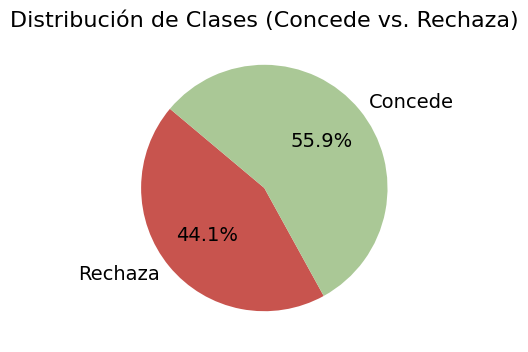

In [ ]:
#Grafico de torta para ver balance del DataSet
# Definir colores pastel
colores = {
    0: '#C8544E',  # Rojo claro pastel para RECHAZA
    1: '#AAC896'   # Azul verdoso pastel para CONCEDE
}

# Obtener los conteos y etiquetas para el gráfico
conteo_etiquetas_plot = df['etiqueta'].value_counts().sort_index()
etiquetas_plot = conteo_etiquetas_plot.index.map({0: 'Rechaza', 1: 'Concede'})
colores_plot = [colores[i] for i in conteo_etiquetas_plot.index]

# Crear el gráfico de torta
plt.figure(figsize=(4, 4))
plt.pie(conteo_etiquetas_plot,
        labels=etiquetas_plot,
        autopct='%1.1f%%',
        colors=colores_plot,
        startangle=140,
        textprops={'fontsize': 14})

plt.title('Distribución de Clases (Concede vs. Rechaza)', fontsize=16)
plt.show()

## Parte 2: Preprocesamiento del Texto






### Capítulo 3: Preprocesamiento, Feature Engineering y Análisis Exploratorio

#### 3.1 Limpieza y Preparación de Texto
---

- Texto original
- Tokenización y limpieza básica (stopwords)
- Limpieza avanzada y filtrado de términos jurídicos
- Creación de textos limpios: básico y final

In [ ]:
# Stopwords en español
stop_words = set(stopwords.words('spanish'))

# --- Función de preprocesamiento ---
def limpiar_texto(texto):
    # Asegurar string
    texto = str(texto)

    # 1. Quitar símbolos y puntuación con regex
    texto = re.sub(r"[^a-zA-ZáéíóúÁÉÍÓÚñÑ\s]", " ", texto)

    # 2. Minúsculas + tokenización
    tokens = word_tokenize(texto.lower(), language="spanish")

    # 3. Filtrar solo palabras alfabéticas y no stopwords
    tokens = [w for w in tokens if w.isalpha() and w not in stop_words]

    # 4. Lematización con spaCy
    doc = nlp(" ".join(tokens))
    tokens_lematizados = [token.lemma_ for token in doc]

    return " ".join(tokens_lematizados)

# --- Aplicar al DataFrame ---
df['texto'] = df['texto'].astype(str) # Ensure the column is string type
df['texto_limpio'] = df['texto'].apply(limpiar_texto)
df['texto_limpio'] = df['texto_limpio'].fillna('').astype(str)

print('Ejemplo (original -> limpio):')
display(df[['texto','texto_limpio']].head(35))

Ejemplo (original -> limpio):


,texto,texto_limpio
0,"""Autos Y Vistos: Proveyendo la presentaciÃ³n e...",auto visto proveer presentaci n electr nico fs...
1,"""AUTOS Y VISTOS: CONSIDERANDO: Dado que son do...",auto visto considerar dar dos requisito exigir...
2,"""AUTOS Y VISTOS: CONSIDERANDO: Dado que son do...",auto visto considerar dar dos requisito exigir...
3,"""AUTOS Y VISTOS: CONSIDERANDO: Dado que son do...",auto visto considerar dar dos requisito exigir...
4,"""QUILMES, en la fecha de la firma digital.\n\n...",quilm fecha firma digital auto visto encontr n...
5,"""AUTOS Y VISTOS: CONSIDERANDO: Dado que son do...",auto visto considerar dar dos requisito exigir...
6,"""QUILMES, EN LA FECHA DE LA FIRMA DIGITAL.-\n\...",quilm fecha firma digital auto visto encontr n...
7,"""QUILMES, en la fecha de la firma digital.\n\n...",quilm fecha firma digital auto visto encontr n...
8,"""QUILMES, en la fecha de la firma digital.-\n\...",quilm fecha firma digital boleta glosado prese...
9,"""AUTOS Y VISTOS: EncontrÃ¡ndose consentida la ...",auto visto encontr ndo él consentido visto con...


In [ ]:
# PASO 1:  Definir las listas de stopwords y la función de limpieza
stop_words_nltk = set(stopwords.words('spanish'))
mis_stopwords_adicionales = {
    'acceso', 'actora', 'afrontar', 'art', 'arts', 'asimismo', 'autos',
    'beneficio', 'carencia', 'caso', 'causa', 'civil', 'comercial', 'conf',
    'conforme', 'consecuencia', 'cpcc', 'cuenta', 'debe', 'derecho', 'dicho', 'ed',
    'efecto', 'ello', 'encuentra', 'fecha', 'fin',
    'forma', 'frente', 'fs', 'gastos', 'gr', 'hacer', 'ii', 'iv', 'inc',
    'juicio', 'justicia', 'ley', 'litigar', 'medio', 'medios', 'mediante',
    'mismo', 'obtenerlos', 'parte', 'pedido', 'peticionante', 'presente', 'principal', 'procesal',
    'proceso', 'puede', 'registrese', 'resuelvo', 'resulta', 'sala', 'ser', 'si', 'sido', 'sino', 'solicita',
    'tal', 'tener', 'vista', 'vistos', 'él', 'el'
}
stop_words_final = stop_words_nltk.union(mis_stopwords_adicionales)

# Función para normalizar texto (solo para limpiezas)
def normalize_text(texto):
    texto = unicodedata.normalize('NFKD', str(texto)).encode('ASCII', 'ignore').decode('ASCII')
    return texto.lower()

# Función de preprocesamiento optimizada
def limpiar_texto(texto, tipo='original'):
    texto_str = str(texto)
    if tipo == 'limpio':
        tokens = word_tokenize(texto_str.lower(), language="spanish")
        tokens = [w for w in tokens if w.isalpha() and w not in stop_words_nltk]
        doc = nlp(" ".join(tokens))
        tokens_lematizados = [token.lemma_.lower() for token in doc if token.lemma_.lower() not in stop_words_nltk]
        return " ".join(tokens_lematizados)
    elif tipo == 'final':
        texto_normalized = normalize_text(texto_str)
        tokens = word_tokenize(texto_normalized, language="spanish")
        tokens = [w for w in tokens if w.isalpha() and w not in stop_words_final]
        doc = nlp(" ".join(tokens))
        tokens_lematizados = []
        for token in doc:
            lemma_parts = token.lemma_.lower().split()
            for part in lemma_parts:
                if part not in stop_words_final:
                    tokens_lematizados.append(part)
        tokens_lematizados = [w for w in tokens_lematizados if w not in stop_words_final]
        return " ".join(tokens_lematizados)
    return texto_str  # Original sin procesar

# PASO 2: Generar las columnas de texto limpio
print("Paso 3: Creando las columnas de texto limpio...")
if 'texto' in df.columns and 'etiqueta' in df.columns:
    df['texto_limpio_basico'] = df['texto'].apply(lambda x: limpiar_texto(x, 'limpio'))
    df['texto_limpio_final'] = df['texto'].apply(lambda x: limpiar_texto(x, 'final'))
    print("Columnas 'texto_limpio_basico' y 'texto_limpio_final' creadas con éxito.")
else:
    print("Error: El DataFrame no contiene las columnas 'texto' o 'etiqueta'.")
    exit()

Paso 3: Creando las columnas de texto limpio...
Columnas 'texto_limpio_basico' y 'texto_limpio_final' creadas con éxito.


#### 3.2 Análisis Inicial de Datos (EDA)
---

- Longitud promedio de texto
- Boxplot para analizar extensión de resoluciones
- Etiquetado gramatical (POS) y dependencias
- Distribución de frecuencias de palabras

In [ ]:
#### 3.2 Análisis Inicial de Datos (EDA)
# Longitud promedio de texto
# Conteo de documentos
num_documentos = len(df)
print(f"Número total de documentos: {num_documentos}\n")

# Longitud promedio del texto
df['longitud_texto'] = df['texto_limpio'].apply(lambda x: len(x.split()))
longitud_promedio = df['longitud_texto'].mean()
print(f"Longitud promedio del texto (en palabras): {longitud_promedio:.2f}")


# Crear la nueva columna con la longitud de cada texto
df['longitud_texto'] = df['texto'].apply(len)

print('DataFrame con la nueva columna:')
print(df.head())

Número total de documentos: 34

Longitud promedio del texto (en palabras): 386.53
DataFrame con la nueva columna:
                                               texto  etiqueta  \
0  "Autos Y Vistos: Proveyendo la presentaciÃ³n e...         1   
1  "AUTOS Y VISTOS: CONSIDERANDO: Dado que son do...         0   
2  "AUTOS Y VISTOS: CONSIDERANDO: Dado que son do...         0   
3  "AUTOS Y VISTOS: CONSIDERANDO: Dado que son do...         0   
4  "QUILMES, en la fecha de la firma digital.\n\n...         1   

                                        texto_limpio  \
0  auto visto proveer presentaci n electr nico fs...   
1  auto visto considerar dar dos requisito exigir...   
2  auto visto considerar dar dos requisito exigir...   
3  auto visto considerar dar dos requisito exigir...   
4  quilm fecha firma digital auto visto encontr n...   

                                 texto_limpio_basico  \
0  auto visto proveer fs vencer plazo conferido f...   
1  auto visto considerar dar dos requisi

In [ ]:
# Obtener estadísticas descriptivas de la longitud de los textos
print('Estadísticas descriptivas de la longitud del texto:')
print(df['longitud_texto'].describe())

Estadísticas descriptivas de la longitud del texto:
count       34.000000
mean      4209.823529
std       5996.533238
min        509.000000
25%       1139.500000
50%       2913.500000
75%       3972.250000
max      32335.000000
Name: longitud_texto, dtype: float64


##### BoxPlot
---

para analizar qué tan extensas son las resoluciones judiciales bajo analisis.


/tmp/ipython-input-1009201326.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='etiqueta', y='longitud_texto', data=df, palette=colores)


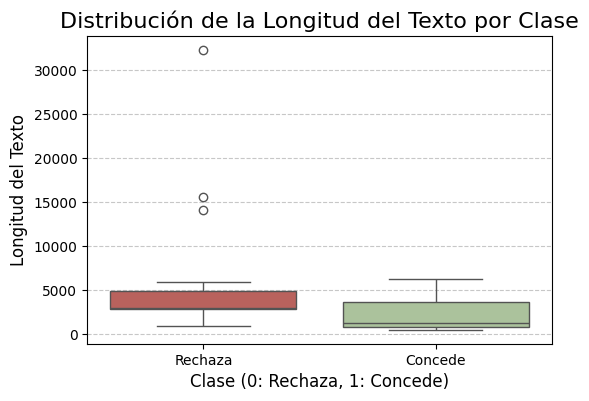

In [ ]:
# Definir colores pastel
colores = {
    '0': '#C8544E',  # Rojo claro pastel para RECHAZA
    '1': '#AAC896'   # Azul verdoso pastel para CONCEDE
}

# Crear el gráfico de caja (box plot)
plt.figure(figsize=(6, 4))
sns.boxplot(x='etiqueta', y='longitud_texto', data=df, palette=colores)

# Personalizar el gráfico para mayor claridad
plt.title('Distribución de la Longitud del Texto por Clase', fontsize=16)
plt.xlabel('Clase (0: Rechaza, 1: Concede)', fontsize=12)
plt.ylabel('Longitud del Texto', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Rechaza', 'Concede'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Se advierte que las resoluciones que conceden son las más cortas de texto. Este elemento podria ser considerado como un elemento que permita identificar la etiqueta 1.

#####Etiquetado gramatical (POS) y dependencias
---


Muestra la estructura lingüística: adjetivos, sustantivos, Y verbos . A tal fin ubicaremos previamente a la resolción con el texto más corto.


In [ ]:
# 1. Encontrar la fila con el texto más corto
# Obtener el índice del texto con la longitud mínima
idx_texto_mas_corto = df['longitud_texto'].idxmin()

# Tomar el texto de esa fila para el análisis
texto_mas_corto = df.loc[idx_texto_mas_corto, 'texto_limpio']

# Procesar el texto con spaCy
doc = nlp(texto_mas_corto)

# 2. Código 1: Tabla simple de tokens
# Generar la tabla de tokens con 'token', 'lemma', 'pos' y 'dep'
rows = [(t.text, t.lemma_, t.pos_, t.dep_) for t in doc if t.text.strip()]
df_tokens = pd.DataFrame(rows, columns=['token', 'lemma', 'pos', 'dep'])

print("--- Tabla de tokens del texto más corto ---")
print(df_tokens.head(15))

# 3. Código 2: Visualizaciones de spaCy

print("\n--- Visualización de Dependencias Gramaticales ---")
displacy.render(doc, style="dep", jupyter=True)

print("\n--- Visualización de Entidades Nombradas ---")
displacy.render(doc, style="ent", jupyter=True)

--- Tabla de tokens del texto más corto ---
          token        lemma    pos       dep
0       proveer      proveer   VERB      ROOT
1    presentaci   presentaci   NOUN       obj
2             n            n   NOUN       obj
3      titulado     titulado    ADJ      amod
4       conceda      conceda   NOUN       obl
5     suscripto    suscripto   NOUN       obj
6       letrado      letrado    ADJ      amod
7           dra          dra  PROPN     appos
8         visto        visto    ADJ      amod
9   conformidad  conformidad   NOUN       obj
10    dispuesto    dispuesto    ADJ      amod
11         arts         arts   NOUN       obj
12            c            c   NOUN  compound
13            p            p   NOUN       dep
14            c            c   NOUN  compound

--- Visualización de Dependencias Gramaticales ---



--- Visualización de Entidades Nombradas ---


#####**Distribución de frecuencias de palabras**
---


Para entender la composición de nuestro vocabulario, calcularemos la frecuencia de cada palabra en el corpus completo. Esto nos ayuda a identificar las palabras más comunes y a tener una visión general de la distribución de palabras. Un histograma es una excelente forma de visualizar esto.

Total de palabras únicas: 2458


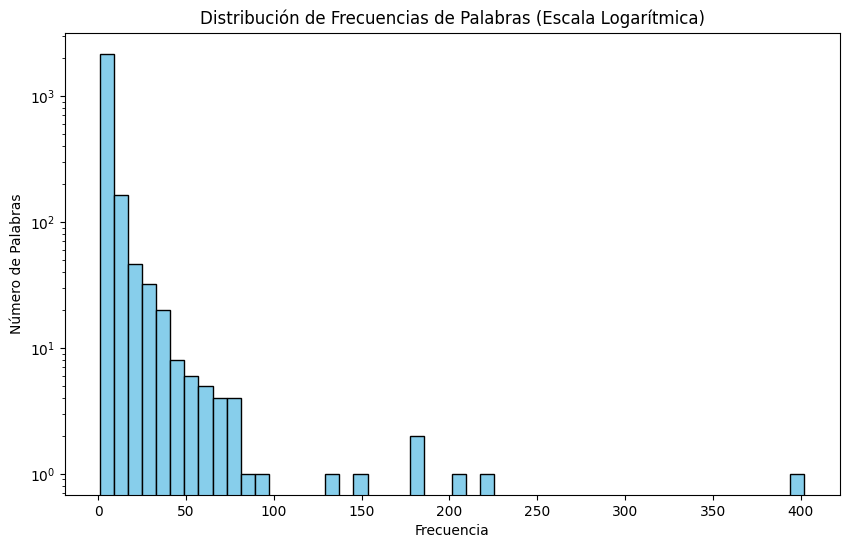

In [ ]:
# Unir todo el texto limpio en un solo string
todo_el_texto = ' '.join(df['texto_limpio'])

# Contar la frecuencia de cada palabra
frecuencia_palabras = Counter(todo_el_texto.split())
print("Total de palabras únicas:", len(frecuencia_palabras))

# Visualizar la distribución de frecuencias
frecuencias = list(frecuencia_palabras.values())
plt.figure(figsize=(10, 6))
plt.hist(frecuencias, bins=50, log=True, color='skyblue', edgecolor='black')
plt.title('Distribución de Frecuencias de Palabras (Escala Logarítmica)')
plt.xlabel('Frecuencia')
plt.ylabel('Número de Palabras')
plt.show()

#### 3.3 Visualización Inicial
---

- Wordclouds por etiqueta (Concede/Rechaza)
- Gráfico de barras comparativo (frecuencias en textos original/básico/final)

##### Distribucion N-gramas
---

 Análisis de N-gramas (Bigramas)

Los N-gramas son secuencias contiguas de N palabras de un texto. Un bigrama (ngram_range=(2,2)) es una secuencia de dos palabras. Este análisis es valioso porque captura el contexto de las palabras, lo que no ocurre con Bag of Words. Por ejemplo, "rechazó la solicitud" es un bigrama que da mucho más sentido que las palabras "rechazó" y "solicitud" por separado.

Aplicaremos CountVectorizer para generar bigramas a partir de la columna texto_limpio.

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/tmp/ipython-input-454018857.py:58: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_df = df_distribucion.style.applymap(color_cells, color=colores['Rechaza (0)'], subset=['Rechaza (0)'])\
/tmp/ipython-input-454018857.py:59: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_cells, color=colores['Concede (1)'], subset=['Concede (1)'])



--- Distribución de los 20 Bigramas más Frecuentes por Etiqueta (Tabla) ---


,Rechaza (0),Concede (1)
registro propiedad,17,10
propiedad inmueble,11,7
insuficiencia recurso,10,3
recurso imposibilidad,9,2
propiedad automotor,8,3
prueba informativo,7,2
constitucional defensa,7,2
ap acuerdo,6,3
acuerdo nro,6,3
alguno aqual,5,3



--- Distribución de los 20 Bigramas más Frecuentes por Etiqueta (Gráfico) ---


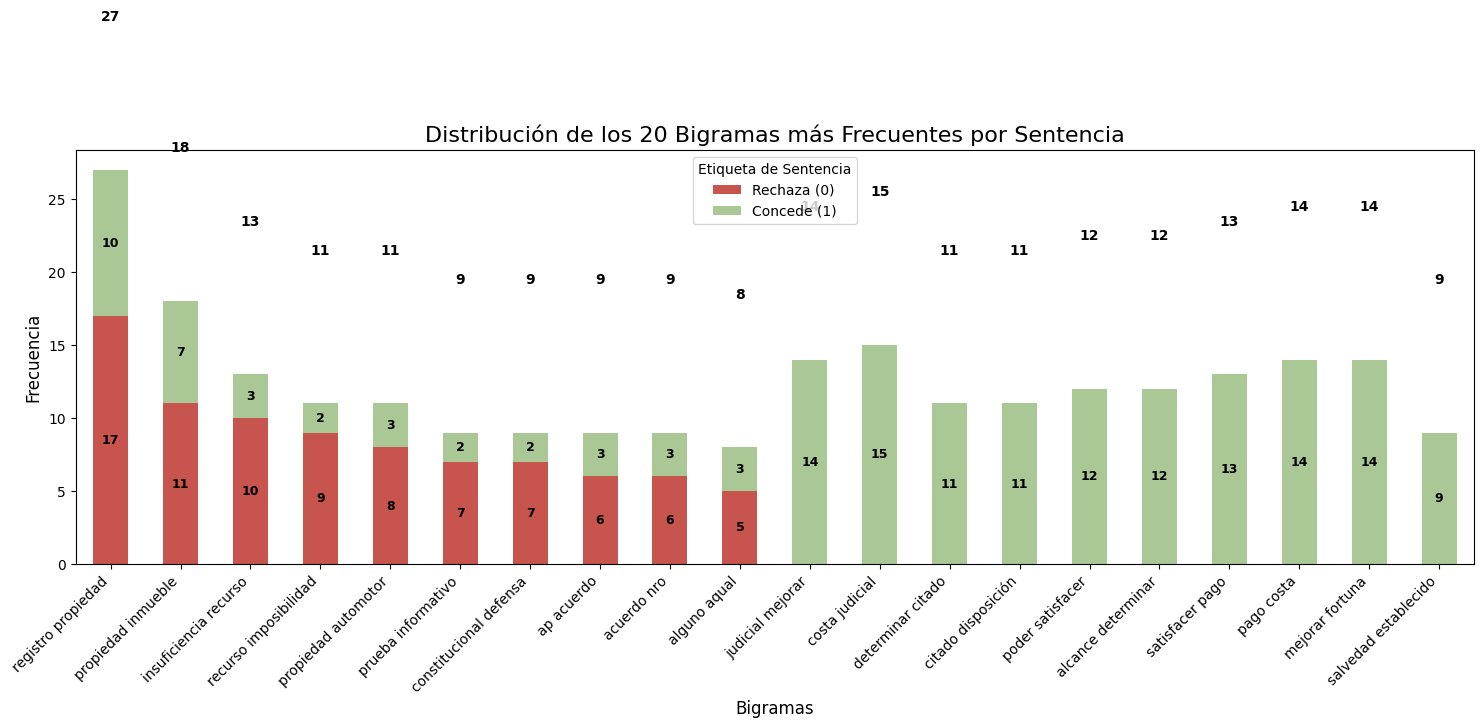

In [ ]:
# Definir la lista completa y actualizada de bigramas a remover
bigramas_a_remover = [
    'litigar gastos', 'beneficio litigar', 'art cpcc', 'autos vistos',
    'parte actora', 'dispuesto arts', 'registrese notifiquese',
    'alcance determinan', 'conds cpc', 'buenos aires',
    'citadas disposiciones', 'determinan citadas', 'mar plata',
    'fortuna salvedad', 'salvedad establecida', 'acuerdos nro',
    'ap acuerdos', 'modif scjba', 'inciso ap', 'nro modif',
    'judiciales mejore', 'suprema corte', 'toda vez',
    'alguno hubiere', 'argto conds', 'carlos camps', 'cumplida martes'
]

# Definir el tokenizer personalizado para remover los bigramas indeseados
def custom_tokenizer_clean(text):
    words = text.split()
    bigrams = [' '.join(words[i:i+2]) for i in range(len(words) - 1)]
    filtered_bigrams = [bigram for bigram in bigrams if bigram not in bigramas_a_remover]
    return filtered_bigrams

# Crear el vectorizador usando el tokenizer personalizado
vectorizer_final = CountVectorizer(tokenizer=custom_tokenizer_clean)

# Aplicar el vectorizador y obtener los top 20 bigramas
X_final = vectorizer_final.fit_transform(df['texto_limpio_final'])
nombres_bigramas_final = vectorizer_final.get_feature_names_out()
conteo_bigramas_final = X_final.sum(axis=0).A1
frecuencia_bigramas_final = sorted(
    zip(nombres_bigramas_final, conteo_bigramas_final),
    key=lambda x: x[1],
    reverse=True
)
top_20_bigramas = [bigrama for bigrama, _ in frecuencia_bigramas_final[:20]]

# --- Visualización de la distribución ---
# Crear el DataFrame para el análisis de frecuencia por etiqueta
df_bigramas = pd.DataFrame(X_final.toarray(), columns=nombres_bigramas_final)
df_bigramas['etiqueta'] = df['etiqueta']

# Filtrar para obtener solo las columnas de los 20 bigramas más frecuentes
df_top_20_bigramas = df_bigramas[top_20_bigramas + ['etiqueta']]

# Agrupar por etiqueta y sumar las frecuencias
df_distribucion = df_top_20_bigramas.groupby('etiqueta').sum().transpose()
df_distribucion.columns = ['Rechaza (0)', 'Concede (1)']
df_distribucion = df_distribucion.sort_values(by='Rechaza (0)', ascending=False)

# Definir colores para tabla y gráfico
colores = {
    'Rechaza (0)': '#C8544E',
    'Concede (1)': '#AAC896'
}

# --- Visualización en tabla ---
print("\n--- Distribución de los 20 Bigramas más Frecuentes por Etiqueta (Tabla) ---")
def color_cells(val, color):
    return f'background-color: {color}'

styled_df = df_distribucion.style.applymap(color_cells, color=colores['Rechaza (0)'], subset=['Rechaza (0)'])\
                                  .applymap(color_cells, color=colores['Concede (1)'], subset=['Concede (1)'])
display(styled_df)

# --- Visualización en gráfico ---
print("\n--- Distribución de los 20 Bigramas más Frecuentes por Etiqueta (Gráfico) ---")
ax = df_distribucion.plot(kind='bar', stacked=True, figsize=(15, 8), color=colores.values())

plt.title('Distribución de los 20 Bigramas más Frecuentes por Sentencia', fontsize=16)
plt.xlabel('Bigramas', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Etiqueta de Sentencia')

# Añadir etiquetas de totales por categoría
for i, rect in enumerate(ax.patches):
    height = rect.get_height()
    width = rect.get_width()
    x = rect.get_x()
    y = rect.get_y()
    if height > 0:
        ax.text(x + width / 2, y + height / 2, f'{int(height)}', ha='center', va='center', fontsize=9, color='black', weight='bold')

total_counts = df_distribucion.sum(axis=1)
for i, total in enumerate(total_counts):
    ax.text(i, total + 10, f'{int(total)}', ha='center', va='bottom', fontsize=10, color='black', weight='bold')

plt.tight_layout()
plt.show()


######Worldcloud y Frecuencia de Palabras
---



Ocurrencias de 'el': 0
Ocurrencias de 'él': 0
Ocurrencias de 'hacer': 0
Top 10 palabras en texto_limpio_final: [('recurso', 79), ('prueba', 62), ('costa', 57), ('poder', 43), ('judicial', 43), ('pago', 40), ('automotor', 37), ('propiedad', 35), ('sociedad', 34), ('considerar', 33)]

--- Paso 4: Generando Nubes de Palabras como visualización inicial ---


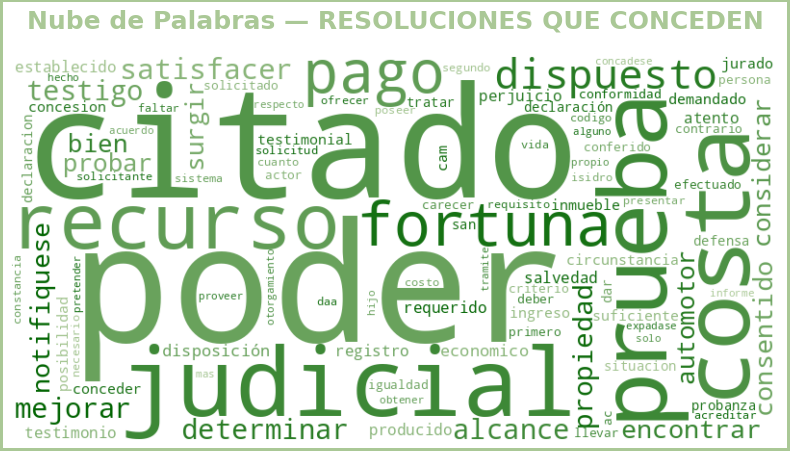

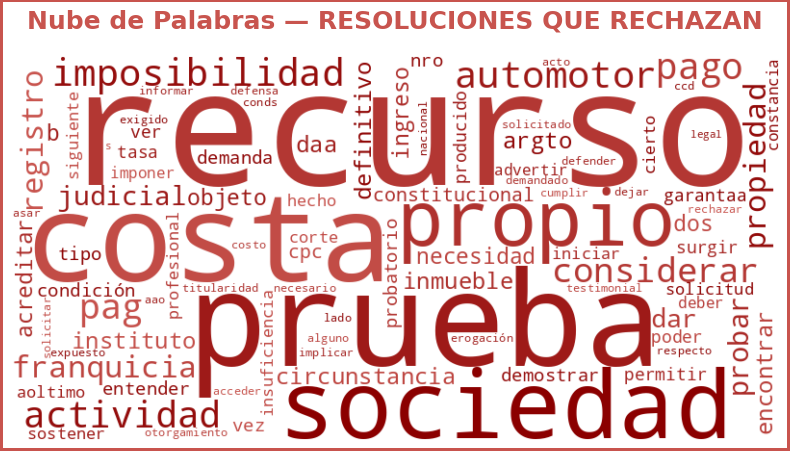


--- Paso 5: Preparando datos para el análisis de frecuencia de palabras ---


/tmp/ipython-input-1818138022.py:71: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_dist = df_dist.fillna(0)
/tmp/ipython-input-1818138022.py:71: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_dist = df_dist.fillna(0)
/tmp/ipython-input-1818138022.py:71: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_dist = df_dist.fillna(0)



--- Paso 6: Generando el gráfico comparativo ---


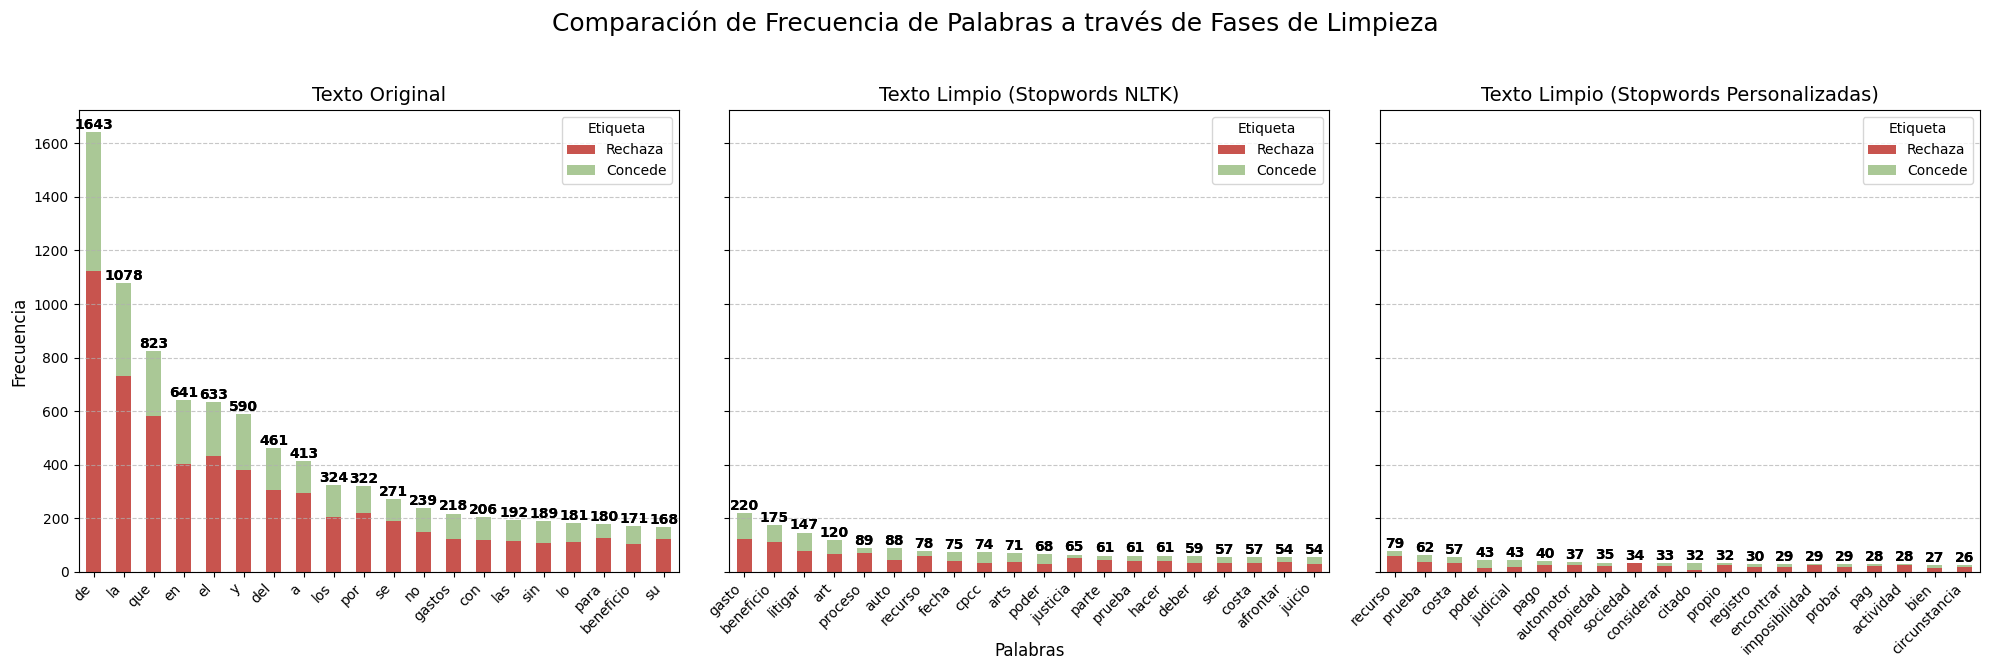

In [ ]:
####Worldcloud y Frecuencia de Palabras

# Verificar la presencia de 'el', 'él' y 'hacer'
print("Ocurrencias de 'el':", df['texto_limpio_final'].str.contains(r'\bel\b', case=False, na=False).sum())
print("Ocurrencias de 'él':", df['texto_limpio_final'].str.contains(r'\bél\b', case=False, na=False).sum())
print("Ocurrencias de 'hacer':", df['texto_limpio_final'].str.contains(r'\bhacer\b', case=False, na=False).sum())

# Verificar las palabras más frecuentes en limpio final
texto_final = ' '.join(df['texto_limpio_final'].astype(str))
frecuencia_palabras = Counter(texto_final.split())
print("Top 10 palabras en texto_limpio_final:", frecuencia_palabras.most_common(10))

# PASO 3: Visualización inicial con Nubes de Palabras
print("\n--- Paso 4: Generando Nubes de Palabras como visualización inicial ---")
colores_clases = {
    0: '#C8544E',  # Rojo claro pastel para RECHAZA
    1: '#AAC896'   # Verde claro pastel para CONCEDE
}
columna_texto_para_wc = 'texto_limpio_final'

concede_text = " ".join(df[df['etiqueta'] == 1][columna_texto_para_wc].dropna().astype(str))
rechaza_text = " ".join(df[df['etiqueta'] == 0][columna_texto_para_wc].dropna().astype(str))

# WordCloud para RESOLUCIONES QUE CONCEDEN
if concede_text.strip():
    cmap_concede = LinearSegmentedColormap.from_list("custom_green", [colores_clases[1], '#006400'])
    wc_concede = WordCloud(
        width=800, height=400, background_color='white',
        colormap=cmap_concede, max_words=100, min_font_size=10,
        contour_width=0, contour_color='white', collocations=False
    ).generate(concede_text)
    fig_concede, ax_concede = plt.subplots(figsize=(12, 5), facecolor='white', edgecolor=colores_clases[1], linewidth=4)
    ax_concede.imshow(wc_concede, interpolation='bilinear')
    ax_concede.axis('off')
    ax_concede.set_title('Nube de Palabras — RESOLUCIONES QUE CONCEDEN', fontsize=18, fontweight='bold', color=colores_clases[1], pad=20)
    plt.show()
else:
    print('No hay textos "concede" para generar wordcloud.')

# WordCloud para RESOLUCIONES QUE RECHAZAN
if rechaza_text.strip():
    cmap_rechaza = LinearSegmentedColormap.from_list("custom_red", [colores_clases[0], '#8B0000'])
    wc_rechaza = WordCloud(
        width=800, height=400, background_color='white',
        colormap=cmap_rechaza, max_words=100, min_font_size=10,
        contour_width=0, contour_color='white', collocations=False
    ).generate(rechaza_text)
    fig_rechaza, ax_rechaza = plt.subplots(figsize=(12, 5), facecolor='white', edgecolor=colores_clases[0], linewidth=4)
    ax_rechaza.imshow(wc_rechaza, interpolation='bilinear')
    ax_rechaza.axis('off')
    ax_rechaza.set_title('Nube de Palabras — RESOLUCIONES QUE RECHAZAN', fontsize=18, fontweight='bold', color=colores_clases[0], pad=20)
    plt.show()
else:
    print('No hay textos "rechaza" para generar wordcloud.')

# PASO 4: Preparar los datos para el gráfico comparativo
print("\n--- Paso 5: Preparando datos para el análisis de frecuencia de palabras ---")

def get_word_frequencies(df_input, text_column, stop_words=None):
    all_text = ' '.join(df_input[text_column].astype(str))
    normalized_text = normalize_text(all_text)
    tokens = [w for w in word_tokenize(normalized_text, language="spanish") if w.isalpha()]

    if stop_words:
        tokens = [w for w in tokens if w not in stop_words]

    frecuencia_total = Counter(tokens)
    top_20_words = [word for word, count in frecuencia_total.most_common(20)]

    df_dist = pd.DataFrame(index=top_20_words, columns=['Rechaza', 'Concede'])
    df_dist = df_dist.fillna(0)

    for _, row in df_input.iterrows():
        text_row = str(row[text_column])
        normalized_text_row = normalize_text(text_row)
        tokens_row = [w for w in word_tokenize(normalized_text_row, language="spanish") if w.isalpha()]

        if stop_words:
            tokens_row = [w for w in tokens_row if w not in stop_words]

        for token in tokens_row:
            if token in top_20_words:
                if row['etiqueta'] == 0:
                    df_dist.loc[token, 'Rechaza'] += 1
                else:
                    df_dist.loc[token, 'Concede'] += 1

    return df_dist.astype(int)

df_dist_original = get_word_frequencies(df, 'texto')
df_dist_basico = get_word_frequencies(df, 'texto_limpio_basico', stop_words=stop_words_nltk)
df_dist_final = get_word_frequencies(df, 'texto_limpio_final', stop_words=stop_words_final)

# PASO 6: Generar el gráfico comparativo
print("\n--- Paso 6: Generando el gráfico comparativo ---")
colores = {'Rechaza': '#C8544E', 'Concede': '#AAC896'}
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

# Función auxiliar para agregar etiquetas totales
def add_total_labels(ax, bars):
    for bar in bars.patches:
        height = bar.get_height()
        if height > 0:
            total_height = sum([b.get_height() for b in bars.patches if b.get_x() == bar.get_x()])
            if total_height > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2, total_height + 0.5,
                    f'{int(total_height)}', ha='center', va='bottom', fontweight='bold', fontsize=10
                )

# Plot original
bars_original = df_dist_original.plot(kind='bar', stacked=True, color=colores, ax=axes[0])
axes[0].set_title('Texto Original', fontsize=14)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].legend(title='Etiqueta')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_xticklabels(df_dist_original.index, rotation=45, ha='right')
add_total_labels(axes[0], bars_original)

# Plot básico
bars_basico = df_dist_basico.plot(kind='bar', stacked=True, color=colores, ax=axes[1])
axes[1].set_title('Texto Limpio (Stopwords NLTK)', fontsize=14)
axes[1].set_xlabel('Palabras', fontsize=12)
axes[1].legend(title='Etiqueta')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_xticklabels(df_dist_basico.index, rotation=45, ha='right')
add_total_labels(axes[1], bars_basico)

# Plot final
bars_final = df_dist_final.plot(kind='bar', stacked=True, color=colores, ax=axes[2])
axes[2].set_title('Texto Limpio (Stopwords Personalizadas)', fontsize=14)
axes[2].legend(title='Etiqueta')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)
axes[2].set_xticklabels(df_dist_final.index, rotation=45, ha='right')
add_total_labels(axes[2], bars_final)

plt.suptitle('Comparación de Frecuencia de Palabras a través de Fases de Limpieza', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#####Histograma de Frecuencias
---


Verificando la existencia de las columnas necesarias...
Generando los histogramas comparativos...


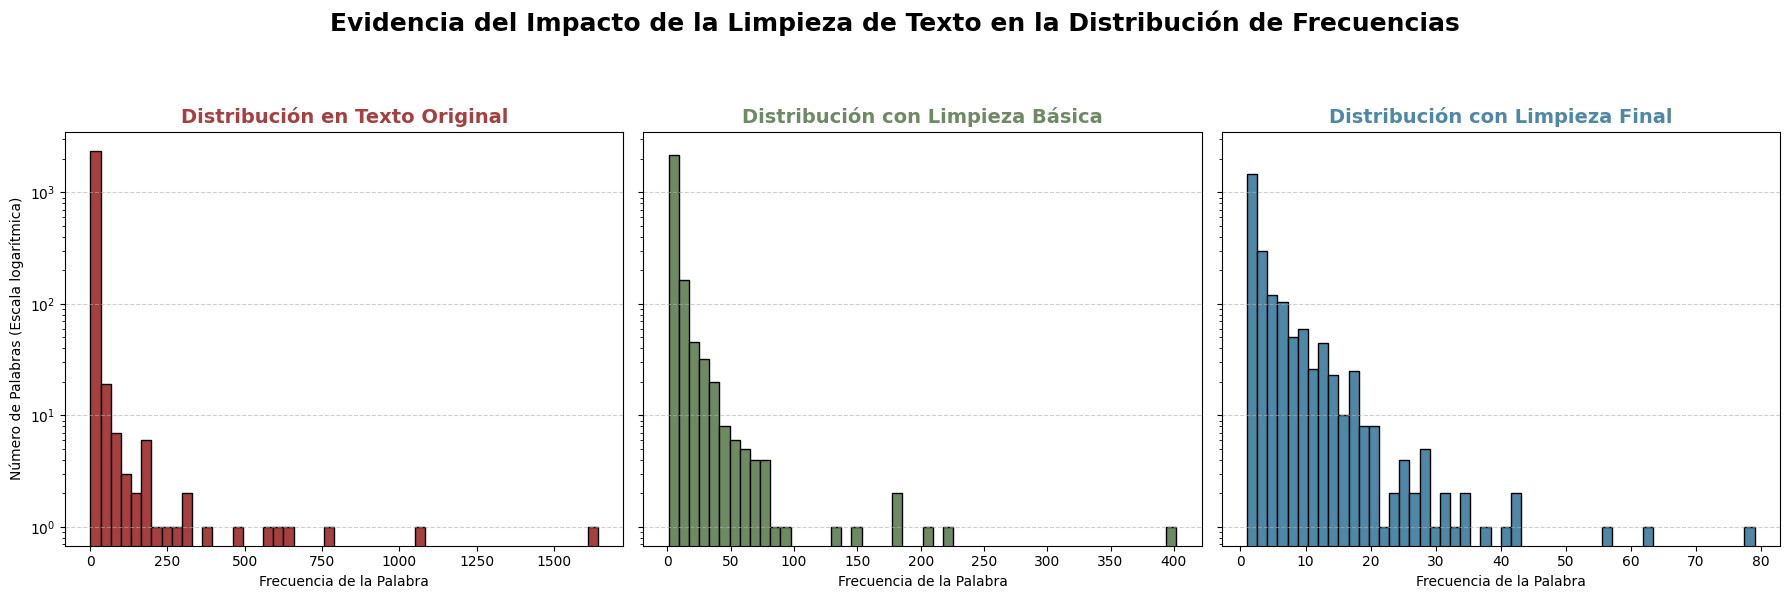

In [ ]:

# Paso 1: Verificar la existencia de las columnas
# ---
print("Verificando la existencia de las columnas necesarias...")
columnas_requeridas = ['texto', 'texto_limpio_basico', 'texto_limpio_final']
for col in columnas_requeridas:
    if col not in df.columns:
        print(f"Error: La columna '{col}' no se encuentra en el DataFrame.")
        # Si la columna no existe, se detiene la ejecución del script.
        exit()

# ---
# Paso 2: Funciones auxiliares para el conteo de frecuencias
# ---
def contar_frecuencias(texto_columna):
    """
    Cuenta la frecuencia de cada palabra en una columna de texto.
    Devuelve un diccionario de palabras y sus frecuencias.
    """
    todo_el_texto = ' '.join(df[texto_columna].dropna().astype(str))
    # Se utiliza un generador para optimizar el procesamiento en memoria
    frecuencia = Counter(word for word in todo_el_texto.lower().split() if word.isalpha())
    return list(frecuencia.values())

# ---
# Paso 3: Generar los histogramas comparativos
# ---
print("Generando los histogramas comparativos...")

# Definir los colores para cada gráfico
colores_paleta = {
    'original': '#A63F3F',      # Rojo oscuro
    'limpio': '#6E8A63',        # Verde oliva
    'final': '#4E88A6'          # Azul medio
}

# Crear una figura con tres subgráficos (1 fila, 3 columnas)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), sharey=True)

# 1. Histograma para el Texto Original
frecuencias_original = contar_frecuencias('texto')
axes[0].hist(frecuencias_original, bins=50, log=True, color=colores_paleta['original'], edgecolor='black')
axes[0].set_title('Distribución en Texto Original', fontsize=14, fontweight='bold', color=colores_paleta['original'])
axes[0].set_xlabel('Frecuencia de la Palabra')
axes[0].set_ylabel('Número de Palabras (Escala logarítmica)')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# 2. Histograma para el Texto Limpio (Básico)
frecuencias_limpio = contar_frecuencias('texto_limpio')
axes[1].hist(frecuencias_limpio, bins=50, log=True, color=colores_paleta['limpio'], edgecolor='black')
axes[1].set_title('Distribución con Limpieza Básica', fontsize=14, fontweight='bold', color=colores_paleta['limpio'])
axes[1].set_xlabel('Frecuencia de la Palabra')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

# 3. Histograma para el Texto Limpio Final
frecuencias_final = contar_frecuencias('texto_limpio_final')
axes[2].hist(frecuencias_final, bins=50, log=True, color=colores_paleta['final'], edgecolor='black')
axes[2].set_title('Distribución con Limpieza Final', fontsize=14, fontweight='bold', color=colores_paleta['final'])
axes[2].set_xlabel('Frecuencia de la Palabra')
axes[2].grid(axis='y', linestyle='--', alpha=0.6)

# Título general del gráfico
plt.suptitle('Evidencia del Impacto de la Limpieza de Texto en la Distribución de Frecuencias', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


#### 3.4 Extracción de Features Derivadas: Organismos Mencionados
---

- Extracción de organismos mencionados
- Conteo de organismos mencionados

### Tabla de recuento de organismos mencionados por tipo de resolución

etiqueta,Rechaza (0),Concede (1)
organismos_mencionados,,
AFIP,4,3
ANSES,1,0
ARBA,2,0
BCRA,2,0
DNRPA,1,0
Registro de la Propiedad Inmueble,5,4


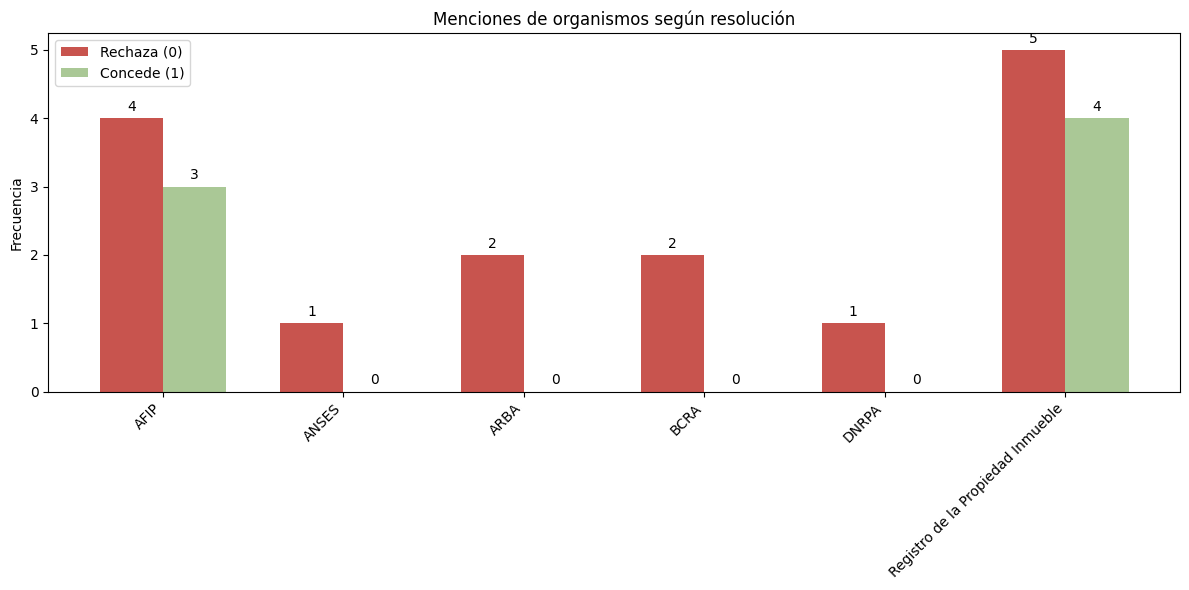

In [ ]:
##Extracción de organismos específicos
organismos = [
    "DNRPA", "AFIP", "DirecciÓn Nacional de Migraciones", "ARBA",
    "BCRA", "Dirección nacional", "Registro de la Propiedad Inmueble", "ANSES"
]

# Función para extraer organismos presentes en un texto
def extraer_organismos(texto):
    encontrados = [org for org in organismos if re.search(r'\b' + re.escape(org) + r'\b', texto)]
    return encontrados

# Aplicar a la columna texto original
df["organismos_mencionados"] = df["texto"].astype(str).apply(extraer_organismos)

# --- 3.2 Crear tabla de recuento cruzado concede/rechaza ---
# Convertimos la lista de organismos en filas individuales para conteo
df_explode = df.explode("organismos_mencionados")

# Tabla cruzada
tabla_resumen = pd.crosstab(
    df_explode["organismos_mencionados"],
    df_explode["etiqueta"],
    dropna=True
).rename(columns={0: "Rechaza (0)", 1: "Concede (1)"})

# Llenar NaN con 0
tabla_resumen = tabla_resumen.fillna(0)

# Mostrar en markdown
display(Markdown("### Tabla de recuento de organismos mencionados por tipo de resolución"))
display(tabla_resumen)

# Definir colores pastel
colores = {
    0: '#C8544E',  # Rojo  claro pastel para RECHAZA
    1: '#AAC896'   # Azul verdoso pastel para CONCEDE
}

# Preparar datos
x = np.arange(len(tabla_resumen))  # Posiciones de los organismos
width = 0.35  # Ancho de las barras

fig, ax = plt.subplots(figsize=(12,6))

# Barras para Rechaza (0)
barras0 = ax.bar(x - width/2, tabla_resumen["Rechaza (0)"], width, label='Rechaza (0)', color=colores[0])
# Barras para Concede (1)
barras1 = ax.bar(x + width/2, tabla_resumen["Concede (1)"], width, label='Concede (1)', color=colores[1])

# Añadir etiquetas sobre cada barra
def add_labels(barras):
    for barra in barras:
        altura = barra.get_height()
        ax.annotate(f'{int(altura)}',
                    xy=(barra.get_x() + barra.get_width()/2, altura),
                    xytext=(0,3),  # Desplazamiento vertical
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(barras0)
add_labels(barras1)

# Ajustes finales
ax.set_ylabel("Frecuencia")
ax.set_title("Menciones de organismos según resolución")
ax.set_xticks(x)
ax.set_xticklabels(tabla_resumen.index, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

#### 3.5 Extracción de Features Derivadas: Concesión Condicional y N-gramas
---

- Detección de concesión condicional (frase clave)
- Análisis inicial de bigramas y exclusión de ruido
- Distribución de bigramas por etiqueta

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



--- Distribución de los 20 Bigramas más Frecuentes por Etiqueta (Gráfico de Barras) ---


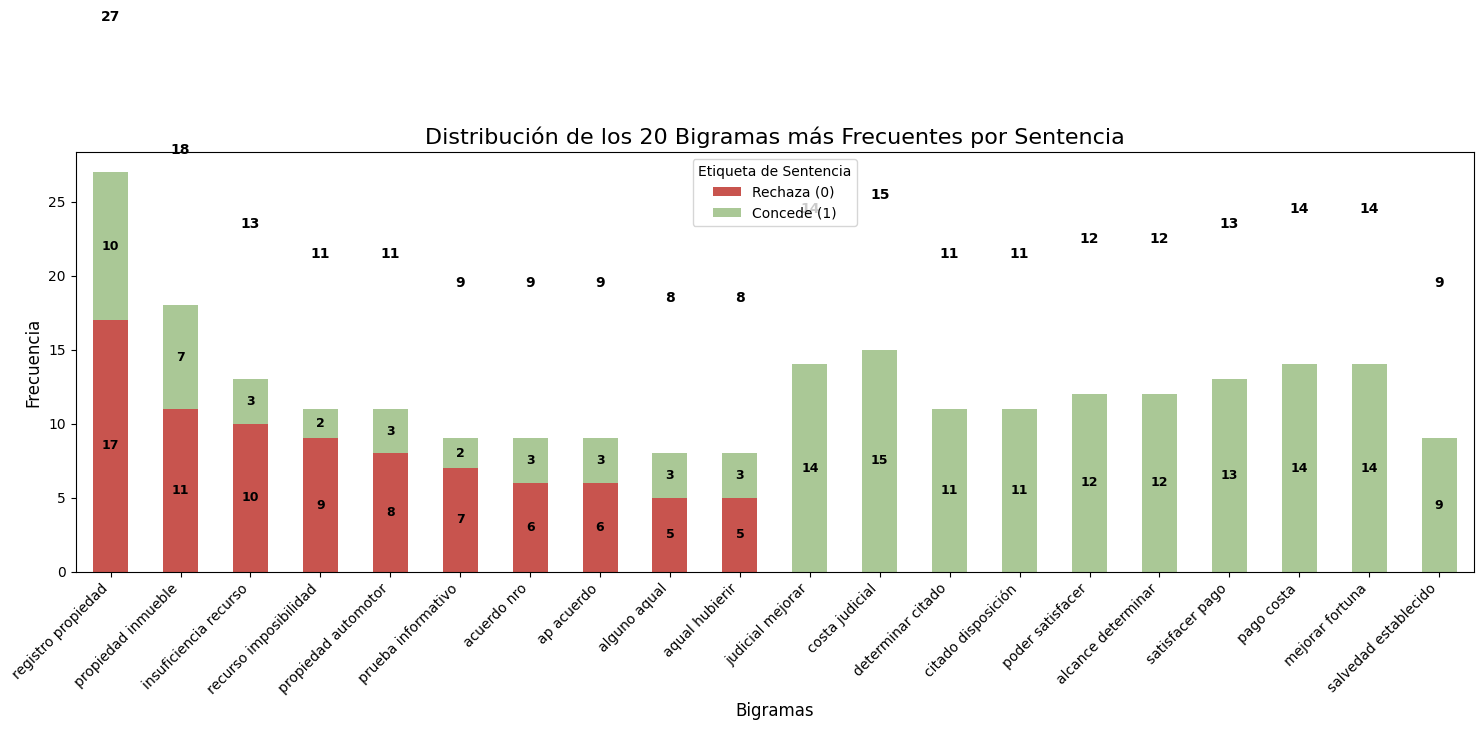


--- Distribución de los 20 Bigramas más Frecuentes por Etiqueta (Tabla) ---
Esta tabla muestra el conteo de los 20 bigramas más comunes por cada tipo de resolución.


/tmp/ipython-input-4030704969.py:120: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_df = df_distribucion.style.applymap(color_cells_table, color=colores['Rechaza (0)'], subset=['Rechaza (0)'])\
/tmp/ipython-input-4030704969.py:121: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_cells_table, color=colores['Concede (1)'], subset=['Concede (1)'])


,Rechaza (0),Concede (1)
registro propiedad,17,10
propiedad inmueble,11,7
insuficiencia recurso,10,3
recurso imposibilidad,9,2
propiedad automotor,8,3
prueba informativo,7,2
acuerdo nro,6,3
ap acuerdo,6,3
alguno aqual,5,3
aqual hubierir,5,3



--- Tabla de Validación (distribución 0/1 por etiqueta) ---
tiene_concesion_condicional   0   1
etiqueta                           
0                            15   0
1                             4  15

--- Casos CONCEDE con concesión condicional detectada ---


,texto_limpio_final
0,proveer encontrar vencido plazo conferido dese...
4,quilm firma digital encontrar consentido confe...
6,quilmes firma encontrar consentido conferido p...
7,quilm firma digital encontrar consentido confe...
8,quilm firma boleto glosado dar cumplido pago b...
9,encontrar consentido conferido probanza dispue...
12,proveer benef efectuado propio patrocinio aten...
13,proveer titulado conceda suscripto letrado con...
15,proveer benef efectuado atento solicitado norm...
21,incidencia marco surgir tomado base pecuniario...


In [ ]:
# -------------------------------
# 1. Creación de la columna 'tiene_concesion_condicional' robusta
# -------------------------------

col_texto = 'texto_limpio_final'

# Lista de patrones flexibles para concesión condicional
condicional_keywords = [
    r"pudiendo\s+satisfacer",
    r"mejor(e|ase|ar)\s+(su\s+)?(fortuna|situaci[oó]n\s+econ[oó]mica|recursos)",
    r"si\s+mejor(a|ase|ar)\s+(su\s+)?(fortuna|situaci[oó]n\s+econ[oó]mica|recursos)",
    r"en\s+caso\s+de\s+mejora\s+(de\s+)?(fortuna|situaci[oó]n\s+econ[oó]mica|recursos)",
    r"supeditad[ao].*mejora\s+(econ[oó]mica|fortuna|recursos)",
    r"condicionad[ao].*mejora\s+(econ[oó]mica|fortuna|recursos)"
]


# Combinar todos los patrones en un solo regex
patron_condicional = re.compile("|".join(condicional_keywords), flags=re.IGNORECASE)

# Función de detección
def detectar_condicional(texto, etiqueta):
    if etiqueta != 1:
        return 0
    if patron_condicional.search(str(texto)):
        return 1
    return 0

# Crear columna binaria
df["tiene_concesion_condicional"] = df.apply(
    lambda row: detectar_condicional(row[col_texto], row["etiqueta"]),
    axis=1
)

# -------------------------------
# 2. Re-análisis de bigramas excluyendo los que son 'ruido'
# -------------------------------

bigramas_a_remover = [
    'litigar gastos', 'beneficio litigar', 'art cpcc', 'autos vistos', 'parte actora',
    'dispuesto arts', 'registrese notifiquese', 'buenos aires', 'mar plata', 'suprema corte',
    'toda vez', 'conds cpc', 'judiciales mejore', 'determinan citadas', 'fortuna salvedad',
    'salvedad establecida', 'ap acuerdos', 'inciso ap', 'alcance deteminan', 'modif scjba',
    'acuerdos nro', 'nro modif', 'alcance determinan', 'argto conds', 'constitucional defensa',
    'alguno hubiere', 'citadas disposiciones', 'carlos camps',
    'cumplida martes', 'hubiere quedado', 'destinatario sistema', 'recursos imposibilidad',
    'disponible destinatario', 'domicilio profesionales', 'disposiciones pudiendo',
    'presentaciones inciso', 'inmediato posterior', 'martes viernes', 'profesionales cumplida',
    'posterior siguiente', 'notificaciones presentaciones', 'derechos propios', 'provincia buenos',
    'quedado disponible', 'siguiente alguno', 'sistema notificaciones', 'viernes inmediato',
    'actuaria acto', 'notifiquese domicilio', 'cam san', 'camps ob', 'ccds carlos', 'san isidro',
    'acto circunstancia', 'archivo adjunto', 'caducidad instancia', 'ccds sociedades',
    'cctes sociedades', 'colab ss', 'comerciales notifiquese', 'consentida conferida',
    'corte resuelto', 'da pie', 'dable destacar', 'deben mencionarse', 'deja inferir',
    'establecida citado', 'informa actuaria', 'jurisprudencia citada', 'rechazar in',
    'defender derechos', 'plata i', 'pick up', 'accionante cierta', 'requerido alcance',
    'b recursos', 'atraviesa empresa', 'b ss', 'cierta entidad', 'circunstancia deja', 'citada igual', 'colab b',
    'concede ciertos'
]


def custom_tokenizer_clean(text):
    words = text.split()
    bigrams = [' '.join(words[i:i+2]) for i in range(len(words) - 1)]
    filtered_bigrams = [bigram for bigram in bigrams if bigram not in bigramas_a_remover]
    return filtered_bigrams

vectorizer_final = CountVectorizer(tokenizer=custom_tokenizer_clean)
X_final = vectorizer_final.fit_transform(df[col_texto])
nombres_bigramas_final = vectorizer_final.get_feature_names_out()
conteo_bigramas_final = X_final.sum(axis=0).A1
frecuencia_bigramas_final = sorted(
    zip(nombres_bigramas_final, conteo_bigramas_final),
    key=lambda x: x[1],
    reverse=True
)
top_20_bigramas = [bigrama for bigrama, _ in frecuencia_bigramas_final[:20]]

# -------------------------------
# 3. Visualización de resultados
# -------------------------------

df_bigramas = pd.DataFrame(X_final.toarray(), columns=nombres_bigramas_final)
df_bigramas['etiqueta'] = df['etiqueta']
df_top_20_bigramas = df_bigramas[top_20_bigramas + ['etiqueta']]
df_distribucion = df_top_20_bigramas.groupby('etiqueta').sum().transpose()
df_distribucion.columns = ['Rechaza (0)', 'Concede (1)']
df_distribucion = df_distribucion.sort_values(by='Rechaza (0)', ascending=False)

colores = {'Rechaza (0)': '#C8544E', 'Concede (1)': '#AAC896'}
print("\n--- Distribución de los 20 Bigramas más Frecuentes por Etiqueta (Gráfico de Barras) ---")
ax = df_distribucion.plot(kind='bar', stacked=True, figsize=(15, 8), color=colores.values())
plt.title('Distribución de los 20 Bigramas más Frecuentes por Sentencia', fontsize=16)
plt.xlabel('Bigramas', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Etiqueta de Sentencia')

for i, rect in enumerate(ax.patches):
    height = rect.get_height()
    width = rect.get_width()
    x = rect.get_x()
    y = rect.get_y()
    if height > 0:
        ax.text(x + width/2, y + height/2, f'{int(height)}', ha='center', va='center', fontsize=9, color='black', weight='bold')

total_counts = df_distribucion.sum(axis=1)
for i, total in enumerate(total_counts):
    ax.text(i, total + 10, f'{int(total)}', ha='center', va='bottom', fontsize=10, color='black', weight='bold')

plt.tight_layout()
plt.show()

print("\n--- Distribución de los 20 Bigramas más Frecuentes por Etiqueta (Tabla) ---")
print("Esta tabla muestra el conteo de los 20 bigramas más comunes por cada tipo de resolución.")

def color_cells_table(val, color):
    return f'background-color: {color}'

styled_df = df_distribucion.style.applymap(color_cells_table, color=colores['Rechaza (0)'], subset=['Rechaza (0)'])\
                                 .applymap(color_cells_table, color=colores['Concede (1)'], subset=['Concede (1)'])
display(styled_df)

# -------------------------------
# 4. Análisis de la característica clave 'tiene_concesion_condicional'
# -------------------------------

tabla_validacion = df.groupby("etiqueta")["tiene_concesion_condicional"].value_counts().unstack(fill_value=0)
print("\n--- Tabla de Validación (distribución 0/1 por etiqueta) ---")
print(tabla_validacion)

print("\n--- Casos CONCEDE con concesión condicional detectada ---")
display(df.loc[(df["etiqueta"] == 1) & (df["tiene_concesion_condicional"] == 1), [col_texto]])

#### 3.6 Validación de Features
---

- Análisis de la característica clave 'tiene_concesion_condicional'


In [ ]:
# División de 0 y 1 en la columna tiene_concesion_condicional por etiqueta
df_division = (
    df.groupby('etiqueta')['tiene_concesion_condicional']
      .value_counts()
      .unstack(fill_value=0)
      .rename(columns={0: "Cantidad_0", 1: "Cantidad_1"})
)

# Imprimir resultado
print(df_division)

tiene_concesion_condicional  Cantidad_0  Cantidad_1
etiqueta                                           
0                                    15           0
1                                     4          15


#### 3.7 Validación con Frecuencias Específicas
---


Esta subsección valida las frecuencias altas en el texto original (1643 para la palabra más común, 168 para la menos frecuente en top 20) vs. decrecientes en limpiezas.

In [ ]:
# Frecuencias en texto original (sin normalizar acentos, solo lower para case-insensitive)
todo_texto_original = ' '.join(df['texto'].astype(str)).lower()
tokens_original = [w for w in word_tokenize(todo_texto_original, language="spanish") if w.isalpha()]
frec_original = Counter(tokens_original)
top_20_original_freq = frec_original.most_common(20)
print("Top 20 frecuencias en Texto Original (validación):")
for word, count in top_20_original_freq:
    print(f"{word}: {count}")

# Comparación rápida con limpio final (decreciente)
todo_texto_final = ' '.join(df['texto_limpio_final'].astype(str))
tokens_final = [w for w in todo_texto_final.split() if w.isalpha()]
frec_final = Counter(tokens_final)
top_20_final_freq = frec_final.most_common(20)
print("\nTop 20 frecuencias en Texto Limpio Final (comparación):")
for word, count in top_20_final_freq:
    print(f"{word}: {count}")


Top 20 frecuencias en Texto Original (validación):
de: 1643
la: 1078
que: 822
en: 641
el: 633
y: 590
del: 461
a: 414
los: 324
por: 322
se: 271
no: 236
gastos: 218
con: 206
las: 192
sin: 189
lo: 181
para: 180
beneficio: 171
su: 168

Top 20 frecuencias en Texto Limpio Final (comparación):
recurso: 79
prueba: 62
costa: 57
poder: 43
judicial: 43
pago: 40
automotor: 37
propiedad: 35
sociedad: 34
considerar: 33
citado: 32
propio: 32
registro: 30
encontrar: 29
imposibilidad: 29
probar: 29
pag: 28
actividad: 28
circunstancia: 26
inmueble: 26


 La validación muestra frecuencias altas en original (1643 max, 168 min en top 20), decreciendo drásticamente en limpio final (79 max), evidenciando el impacto de las limpiezas para reducir ruido y resaltar features predictivas.

#### 3.8 Conclusiones
---

- Conclusiones del impacto de la limpieza de texto
- Descubrimiento de patrones clave (organismos, bigramas, features)
- Conclusión general del preprocesamiento y análisis

#### Pipeline Integral de NLP aplicado a Textos Judiciales
---

Este capítulo consolidó un **pipeline integral de procesamiento de lenguaje natural (NLP)** aplicado a textos judiciales, transformando datos crudos en información valiosa para la clasificación de resoluciones en **"Concede" (1)** o **"Rechaza" (0)**.  
A través de un flujo estructurado —desde la limpieza inicial (3.1) hasta la validación de features (3.6 y 3.7)— se aplicaron técnicas de **preprocesamiento de NLP** (tokenización, remoción de stopwords, lematización), se realizó **análisis exploratorio (EDA)**, se generaron **visualizaciones ejecutivas**, y se extrajeron **insights clave** para un modelo supervisado.  

A continuación, se resumen los hallazgos, conectando cada etapa con su impacto en el análisis y la preparación para el modelado predictivo.

---

#### Impacto de la Limpieza de Texto (3.1, 3.3)

La limpieza fue la **base del análisis**, transformando textos judiciales ruidosos en datos estructurados y significativos:

- **Limpieza inicial (3.1):**  
  - Eliminación de símbolos, puntuación y stopwords genéricas (NLTK).  
- **Limpieza avanzada:**  
  - Lista personalizada de términos legales irrelevantes (*"autos vistos"*, *"registrese notifiquese"*).  
- **Tokenización y lematización (spaCy):**  
  - Reducción de dimensionalidad del vocabulario (ej. *"personas"* → *"persona"*).  

**Evidencias**:  
- Texto original → Distribución sesgada con alta frecuencia (máx. 1643).  
- Limpieza básica → Reducción de la “cola larga”.  
- Limpieza final → Distribución aplanada (máx. 79), resaltando palabras clave.  

Resultado: **Corpus optimizado** para técnicas avanzadas como **TF-IDF**.

---

#### Análisis Exploratorio de Datos (EDA) y Visualizaciones (3.2, 3.3)

El análisis inicial reveló **patrones estructurales**:

- Dataset: **34 documentos**, longitud promedio **4209 caracteres** (rango: 509 – 32,335).  
- Diferencia clave:  
  - **"Concede"** → resoluciones más **cortas**.  
  - **"Rechaza"** → resoluciones más **extensas**.  

**Hallazgos**:  
- Longitud del texto identificada como **predictor potencial**.  
- POS tagging mostró complejidad gramatical y términos condicionales (ej. *"pudiendo"*, *"fortuna"*).  

**Visualizaciones**:  
- **Wordclouds:** Diferenciaron vocabulario por clase.  
- **Gráficos de barras:** Resaltaron cómo la limpieza avanzó en vocabulario discriminativo.  

Resultado: Visualizaciones ejecutivas que responden preguntas de interés.

---

#### Descubrimiento de Patrones Clave: Organismos y N-gramas (3.4, 3.5)

##### Organismos (3.4)  
- **"Rechaza"**: ANSES, ARBA, BCRA, DNRPA.  
- **Menor poder discriminatorio**: AFIP, Registro de la Propiedad.  

##### N-gramas (3.5)  
- **Rechaza** → *"registro propiedad"*, *"prueba informativa"*.  
- **Concede** → *"pudiendo satisfacer"*, *"mejore fortuna"*, *"pago costas"*.  

**Visualizaciones**: Tablas cruzadas y gráficos de barras confirmaron la hipótesis:  
**Patrones lingüísticos específicos diferencian las clases.**

---

#### Feature Engineering y Validación (3.5, 3.6, 3.7)

- Creación de variable binaria: **`tiene_concesion_condicional`**.  
  - Detectó con éxito **15 de 19 "Concede"**.  
  - Cero falsos positivos en "Rechaza".  
- Validación (3.6, 3.7):  
  - Confirmó la **eficacia de la limpieza**.  
  - Reducción drástica de frecuencias irrelevantes (1643 → 79).  

Resultado: Features con **alto poder predictivo** para el modelo supervisado.

---

#### Conclusión General

El pipeline **transformó un conjunto desordenado de textos judiciales** en una **base sólida para clasificación supervisada**:

1. **Limpieza inicial (3.1):** Eliminación de ruido.  
2. **EDA (3.2):** Identificación de la longitud como predictor.  
3. **Visualizaciones (3.3):** Diferenciación clara por clase.  
4. **Features derivadas (3.4, 3.5):** Patrones lingüísticos y condicionales revelados.  
5. **Validación (3.6, 3.7):** Consolidación de la efectividad del pipeline.  
El análisis exploratorio confirma que la limpieza de texto fue efectiva: en el texto original, palabras como "de" (1643 apariciones) y "la" (1078) dominan, pero son poco informativas. En cambio, en `texto_limpio_final`, términos como "recurso" (79), "prueba" (62) y "costa" (57) destacan, reflejando conceptos legales clave. La incorporación de features derivadas, como `tiene_concesion_condicional` y `num_organismos_mencionados`, enriquece el dataset al capturar señales específicas (por ejemplo, menciones de organismos como AFIP o frases condicionales). Estas características serán clave para los modelos de clasificación en los capítulos siguientes.
---

**Impacto Final**  
Este trabajo busca responder preguntas iniciales sobre los **patrones lingüísticos en resoluciones judiciales** y establecer una base técnica para el modelado predictivo utilizando métodos como **TF-IDF y redes neuronales**.  

Aunque aún hay mucho camino por recorrer, se demuestra que mediante la utilización de técnicas de NLP se pueden obtener **insights útiles para la comunidad jurídica** interesada en la automatización.  

Este esfuerzo pretende ser una contribución modesta pero significativa que aporte al entendimiento y avance en la aplicación de inteligencia artificial en el ámbito judicial.


## Parte 3: Vectorización y Preparación para Modelos
---


### Capítulo 4: Vectorización TF-IDF
---

- Justificación del uso de texto_limpio_final
- Construcción de la matriz TF-IDF
- Integración de características numéricas (e.g., longitud_texto, tiene_concesion_condicional)
- Combinación de matrices para modelado

####Analisis de las columnas existentes hasta el momento.







In [ ]:
# Encabezado del reporte para mayor claridad
print("--- RESUMEN DEL DATAFRAME ---")

print("\n1. Dimensiones (Filas, Columnas):")
# Ahora sí, imprime la forma del DataFrame
print(df.shape)

print("\n2. Información general y tipos de datos:")
# Muestra el resumen completo del DataFrame
df.info()

print("\n3. Conteo de valores nulos por columna:")
# Cuenta cuántos valores nulos hay en cada columna
print(df.isnull().sum())

print("\n4. Primeras 5 filas para una vista rápida:")
# Muestra las primeras 5 filas (puedes cambiar el 5)
print(df.head())

--- RESUMEN DEL DATAFRAME ---

1. Dimensiones (Filas, Columnas):
(34, 8)

2. Información general y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   texto                        34 non-null     object
 1   etiqueta                     34 non-null     int64 
 2   texto_limpio                 34 non-null     object
 3   texto_limpio_basico          34 non-null     object
 4   texto_limpio_final           34 non-null     object
 5   longitud_texto               34 non-null     int64 
 6   organismos_mencionados       34 non-null     object
 7   tiene_concesion_condicional  34 non-null     int64 
dtypes: int64(3), object(5)
memory usage: 2.3+ KB

3. Conteo de valores nulos por columna:
texto                          0
etiqueta                       0
texto_limpio                   0
texto_limpio_basico    

#### Proceso de Vectorización (TF-IDF)

---

#### Justificación para el Uso de la Columna `texto_limpio_final` en la Vectorización y Modelado

Para construir y ajustar el `TfidfVectorizer`, se elige la columna `texto_limpio_final` como base del análisis y modelado. Esta decisión proviene de un proceso riguroso de limpieza y refinamiento textual, que garantiza que el modelo trabaje con información relevante y predictiva.

##### Proceso de Limpieza y Selección

- **Columna texto (Texto Original):** Texto íntegro extraído de resoluciones judiciales, sin procesamiento.  
- **Columna texto_limpio (Limpieza Inicial):** Resultado de la primera fase, que incluye tokenización y eliminación de stopwords genéricas en español.  
- **Columna texto_limpio_final (Limpieza Avanzada):** Limpieza exhaustiva que elimina stopwords básicas y términos específicos del dominio jurídico poco útiles para el análisis.

##### Por qué `texto_limpio_final` es la Mejor Opción

- **Calidad superior de la información:** Minimiza ruido, maximizando términos con valor discriminativo.  
- **Reducción de dimensionalidad irrelevante:** Evita sobrecargar el modelo con características genéricas o poco útiles.  
- **Representación semántica más fiel:** Refleja con mayor precisión el contenido clave de las resoluciones.  
- **Consistencia con análisis previos:** Alineado con la identificación previa de patrones basados en bigramas y términos relevantes.

---

#### Integración de Características Numéricas Adicionales

Para optimizar el modelo, es clave combinar la matriz de características de texto (`X_tfidf`) con las características numéricas preparadas. Esta integración debe hacerse **después de generar la matriz TF-IDF** y **antes de dividir el dataset para entrenamiento**.

Las características numéricas a integrar son:

- `longitud_texto`  
- `organismos_mencionados`  
- `tiene_concesion_condicional`  

Esta combinación enriquece el modelo con información textual y numérica, mejorando su capacidad predictiva y rendimiento.


####Combinación de Características y Vectorización
---
Se limitó a **1000 features** para reducir la dimensionalidad y evitar el **sobreajuste** en un dataset pequeño.


In [ ]:
# --- 1. Preprocesamiento de la columna 'organismos_mencionados' ---
# Convertimos cada lista en esta columna a un conteo numérico.
# Si el valor no es una lista, se mantiene como está.
df['num_organismos_mencionados'] = df['organismos_mencionados'].apply(lambda x: len(x) if isinstance(x, list) else x)

# --- 2. Vectorización TF-IDF de la columna de texto ---
# Usamos la columna 'texto_limpio_final' para crear la matriz TF-IDF.
vectorizer_tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = vectorizer_tfidf.fit_transform(df['texto_limpio_final'])

# --- 3. Extraer las características numéricas ---
# Seleccionamos las columnas numéricas que se usarán en la combinación.
numerical_features = ['longitud_texto', 'num_organismos_mencionados', 'tiene_concesion_condicional']
X_numericas_df = df[numerical_features]

# --- 4. Combinar las características numericas ---
# Convertimos las características numéricas a una matriz dispersa `csr_matrix`.
X_numericas_sparse = csr_matrix(X_numericas_df.values)

# Unimos la matriz de TF-IDF con las nuevas características numéricas.
X_combined = hstack([X_tfidf, X_numericas_sparse])

# A partir de este punto, X_combined es la matriz de características completa
# lista para ser utilizada en el entrenamiento de tu modelo.
print("Características numéricas seleccionadas:", numerical_features)
print("Forma de la matriz de características TF-IDF:", X_tfidf.shape)
print("Forma de la matriz de características numéricas:", X_numericas_sparse.shape)
print("Forma de la matriz combinada final:", X_combined.shape)

Características numéricas seleccionadas: ['longitud_texto', 'num_organismos_mencionados', 'tiene_concesion_condicional']
Forma de la matriz de características TF-IDF: (34, 1000)
Forma de la matriz de características numéricas: (34, 3)
Forma de la matriz combinada final: (34, 1003)



### Pasos aplicados en la combinación de características

---

**Paso 1: Preparar la Columna de Organismos**  
Los modelos de machine learning solo entienden números. La columna `organismos_mencionados` contiene listas (por ejemplo, `['AFIP', 'BCRA']`), que un modelo no puede procesar directamente.  

Este paso consiste en contar la cantidad de organismos en cada lista y crear una nueva columna llamada `num_organismos_mencionados` con ese conteo. Por ejemplo, si una fila contiene `['AFIP', 'BCRA']`, la nueva columna tendrá el valor 2.

---

**Paso 2: Convertir el Texto en Números (TF-IDF)**  
Este es el núcleo del proceso. La técnica TF-IDF (Frecuencia de Término - Frecuencia Inversa de Documento) analiza la columna de texto `texto_limpio_final`.  

Su objetivo es transformar cada documento en una serie de números, asignando un valor a cada palabra basado en:  
- La frecuencia de la palabra en el documento.  
- Qué tan rara es esa palabra en todo el conjunto de documentos.  

Palabras importantes (como nombres específicos) reciben un valor alto, mientras que palabras comunes (como "de" o "la") tienen un valor bajo.  

El resultado es una matriz donde cada fila es un documento, cada columna es una palabra y los valores representan la importancia relativa de esa palabra.

---

**Paso 3: Unir las Piezas**  
Una vez generada la matriz numérica del texto y preparadas las columnas numéricas (`longitud_texto`, `num_organismos_mencionados`, `tiene_concesion_condicional`), el último paso es unirlas.  

Se utiliza `hstack` para apilar estas matrices lado a lado, creando una única matriz final que contiene tanto la información numérica extraída del texto como las características numéricas originales.

---

En resumen, este proceso transforma el texto y las características adicionales en una matriz numérica completa que el modelo de clasificación puede procesar para aprender a predecir correctamente la etiqueta.  

El siguiente paso lógico es preparar los datos a partir de esta matriz para entrenar y evaluar el modelo.


####Pasos aplicados en la combinación de características:

#### Paso 1: Preparar la Columna de Organismos

Los modelos de machine learning solo entienden números. La columna `organismos_mencionados` contiene listas (por ejemplo, `['AFIP', 'BCRA']`), que un modelo no puede procesar directamente. Este primer paso consiste en contar la cantidad de organismos en cada lista y crear una nueva columna llamada `num_organismos_mencionados` con ese conteo. Por ejemplo, si una fila contenía `['AFIP', 'BCRA']`, la nueva columna tendrá el valor 2.

#### Paso 2: Convertir el Texto en Números (TF-IDF)

Este es el núcleo del proceso. La técnica TF-IDF (Frecuencia de Término - Frecuencia Inversa de Documento) analiza la columna de texto `texto_limpio_final`. Su objetivo es transformar cada documento de texto en una serie de números, asignando un valor a cada palabra basado en:

- La frecuencia de la palabra en el documento.
- Qué tan rara es esa palabra en todo el conjunto de documentos.

Las palabras importantes (como nombres específicos) reciben un valor alto, mientras que las palabras comunes (como "de" o "la") tienen un valor bajo. El resultado es una matriz donde cada fila es un documento, cada columna es una palabra y los valores representan la importancia relativa de esa palabra.

#### Paso 3: Unir las Piezas

Una vez generada la matriz numérica del texto y preparadas las columnas numéricas (`longitud_texto`, `num_organismos_mencionados`, `tiene_concesion_condicional`), el último paso es unirlas. Se utiliza `hstack` para apilar estas matrices una al lado de la otra, creando una única matriz final que contiene tanto la información numérica extraída del texto como las características numéricas originales.

En resumen, este proceso toma el texto y las características adicionales, y las transforma en una matriz numérica completa que el modelo de clasificación puede procesar para aprender a predecir la etiqueta correctamente.

El siguiente paso lógico será preparar los datos a partir de esta matriz para entrenar y evaluar el modelo.


### Capítulo 5: Preparación de Datos para Entrenamiento
---

- División y validación cruzada estratificada
- Manejo de valores nulos y formatos
- Conversión a formatos adecuados para modelos (numpy arrays para DL)

In [ ]:
# Encabezado del reporte para mayor claridad
print("--- RESUMEN DEL DATAFRAME ---")

print("\n1. Dimensiones (Filas, Columnas):")
# Ahora sí, imprime la forma del DataFrame
print(df.shape)

print("\n2. Información general y tipos de datos:")
# Muestra el resumen completo del DataFrame
df.info()

print("\n3. Conteo de valores nulos por columna:")
# Cuenta cuántos valores nulos hay en cada columna
print(df.isnull().sum())

--- RESUMEN DEL DATAFRAME ---

1. Dimensiones (Filas, Columnas):
(34, 9)

2. Información general y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   texto                        34 non-null     object
 1   etiqueta                     34 non-null     int64 
 2   texto_limpio                 34 non-null     object
 3   texto_limpio_basico          34 non-null     object
 4   texto_limpio_final           34 non-null     object
 5   longitud_texto               34 non-null     int64 
 6   organismos_mencionados       34 non-null     object
 7   tiene_concesion_condicional  34 non-null     int64 
 8   num_organismos_mencionados   34 non-null     int64 
dtypes: int64(4), object(5)
memory usage: 2.5+ KB

3. Conteo de valores nulos por columna:
texto                          0
etiqueta                       0

In [ ]:
### Capítulo 5: Preparación de Datos para Entrenamiento
# Justificación: Usamos validación cruzada estratificada (SKF 5-folds) para datasets pequeños (34 resoluciones BLSG), manteniendo balance de clases (15 rechazos, 19 concesiones). Creamos X_combined_dense con TF-IDF y features numéricas, verificamos nulos por split para robustez, y preparamos datos para modelado. No escalamos features numéricas por dominio TF-IDF, planificando StandardScaler para mejoras futuras.

# Verificar que 'etiqueta' existe y es correcta
if 'etiqueta' not in df.columns:
    raise ValueError("La columna 'etiqueta' no existe en el DataFrame. Verifica la carga de datos.")
if df['etiqueta'].isnull().any():
    raise ValueError("La columna 'etiqueta' contiene valores nulos. Verifica el preprocesamiento.")

# Definir y verificar y
y = df['etiqueta'].values  # Columna binaria: 1=Concede, 0=Rechaza
print("Forma de y:", y.shape)
print("Valores únicos en y:", np.unique(y))
if not isinstance(y, np.ndarray) or y.ndim != 1 or len(y) != 34:
    raise ValueError(f"y debe ser un array 1D de longitud 34, pero tiene forma {y.shape}")

# Crear X_combined_dense
if 'num_organismos_mencionados' not in df.columns:
    df['num_organismos_mencionados'] = df['organismos_mencionados'].apply(lambda x: len(x) if isinstance(x, list) else x)

vectorizer_tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = vectorizer_tfidf.fit_transform(df['texto_limpio_final'])

numerical_features = ['longitud_texto', 'num_organismos_mencionados', 'tiene_concesion_condicional']
X_numericas_df = df[numerical_features]
X_numericas_sparse = csr_matrix(X_numericas_df.values)

X_combined = hstack([X_tfidf, X_numericas_sparse])
X_combined_dense = X_combined.toarray()

print("Forma de X_combined_dense:", X_combined_dense.shape)
if X_combined_dense.shape[0] != 34:
    raise ValueError(f"X_combined_dense debe tener 34 filas, pero tiene {X_combined_dense.shape[0]}")

# Preparar SKF para CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Nota sobre Escalado: No aplicado por impacto mínimo de 3 features numéricas vs. 1000 TF-IDF; futuro con StandardScaler para estabilidad.

# Verificación de nulos global y por split
print("Nulos globales en dataset:", df.isnull().sum().sum())
for fold, (train_index, test_index) in enumerate(skf.split(X_combined_dense, y), 1):
    X_train, X_test = X_combined_dense[train_index], X_combined_dense[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Verificación de nulos por split
    print(f"\nFold {fold}:")
    print("Nulos en X_train:", np.isnan(X_train).sum())
    print("Nulos en X_test:", np.isnan(X_test).sum())
    print("Forma de X_train:", X_train.shape)
    print("Forma de X_test:", X_test.shape)

    # Cálculo de pesos de clase (compatible con tu código)
    classes = np.unique(y_train)
    class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    print(f"Pesos de clase: {class_weight_dict}")

# Conclusión: Datos listos con CV estratificada, X_combined_dense creado (34, 1003), y verificación de nulos por split, ideal para clasificar resoluciones BLSG en Colab.

Forma de y: (34,)
Valores únicos en y: [0 1]
Forma de X_combined_dense: (34, 1003)
Nulos globales en dataset: 0

Fold 1:
Nulos en X_train: 0
Nulos en X_test: 0
Forma de X_train: (27, 1003)
Forma de X_test: (7, 1003)
Pesos de clase: {0: np.float64(1.125), 1: np.float64(0.9)}

Fold 2:
Nulos en X_train: 0
Nulos en X_test: 0
Forma de X_train: (27, 1003)
Forma de X_test: (7, 1003)
Pesos de clase: {0: np.float64(1.125), 1: np.float64(0.9)}

Fold 3:
Nulos en X_train: 0
Nulos en X_test: 0
Forma de X_train: (27, 1003)
Forma de X_test: (7, 1003)
Pesos de clase: {0: np.float64(1.125), 1: np.float64(0.9)}

Fold 4:
Nulos en X_train: 0
Nulos en X_test: 0
Forma de X_train: (27, 1003)
Forma de X_test: (7, 1003)
Pesos de clase: {0: np.float64(1.125), 1: np.float64(0.9)}

Fold 5:
Nulos en X_train: 0
Nulos en X_test: 0
Forma de X_train: (28, 1003)
Forma de X_test: (6, 1003)
Pesos de clase: {0: np.float64(1.1666666666666667), 1: np.float64(0.875)}


### Capítulo 5: Preparación de Datos para Entrenamiento
---


En este capítulo se detallan los pasos para preparar los datos de manera adecuada para el entrenamiento de los modelos de Regresión Logística (RL) y Red Neuronal (NN). Se prioriza la reproducibilidad, la integridad de los datos y la compatibilidad con ambos algoritmos, optimizando para un dataset pequeño (34 resoluciones BLSG).

#### Ingeniería de Características
---

Se parte de un DataFrame con 9 columnas, incluyendo `texto_limpio_final` (texto procesado), `etiqueta` (binaria: 0=Rechaza, 1=Concede), y características derivadas como `longitud_texto`, `num_organismos_mencionados` y `tiene_concesion_condicional`, que capturan señales relevantes para la clasificación de resoluciones BLSG.

#### Vectorización y Combinación de Características
---

La columna `texto_limpio_final` se transforma en una matriz sparse de TF-IDF usando `TfidfVectorizer(max_features=1000)`, capturando los 1000 términos más relevantes (e.g., "prueba", "costa"). Las features numéricas (`longitud_texto`, `num_organismos_mencionados`, `tiene_concesion_condicional`) se convierten a una matriz sparse con `csr_matrix` y se combinan con la matriz TF-IDF mediante `hstack`, generando `X_combined` (34, 1003). Para la Red Neuronal, se convierte `X_combined` a una matriz densa (`X_combined_dense`) con `.toarray()`, cumpliendo los requisitos de entrada de Keras.

#### División y Validación Cruzada Estratificada
---

Se implementa validación cruzada estratificada con `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`, asegurando que cada fold mantenga la proporción de clases (15 rechazos, 19 concesiones). El parámetro `random_state=42` garantiza reproducibilidad, y `shuffle=True` evita sesgos en la distribución.

#### Verificación de Datos
---

Se verificaron nulos globalmente (`df.isnull().sum() == 0`) y por split en cada fold (`np.isnan(X_train).sum() == 0`, `np.isnan(X_test).sum() == 0`), confirmando la integridad de los datos. La forma de `X_combined_dense` (34, 1003) y `y` (34,) es consistente, con splits de ~27-28 muestras en entrenamiento y ~6-7 en prueba por fold. Los pesos de clase (`compute_class_weight`) manejan el desbalance, asignando mayor peso a la clase minoritaria (Rechaza).

#### Resumen
---

Los datos están preparados con una matriz combinada (34, 1003) de features textuales (TF-IDF) y numéricas, verificada para nulos y formas correctas. La validación cruzada estratificada asegura robustez en datasets pequeños, siendo ideal para clasificar resoluciones BLSG en Colab. RL usa la matriz sparse (`X_combined`) directamente, mientras que NN requiere la matriz densa (`X_combined_dense`), garantizando compatibilidad con ambos modelos.

### *Nota sobre Escalado*

> Las features numéricas no fueron escaladas en esta versión debido al dominio de las features TF-IDF (1000 columnas vs. 3 numéricas), lo que minimizó su impacto en los modelos. En futuros trabajos, se recomienda implementar `StandardScaler` para optimizar la convergencia.


### Parte 4: Modelado y Evaluación


### Capítulo 6: Modelo Baseline - Regresión Logística
---

- Definición del modelo
- Entrenamiento y validación cruzada
- Métricas de desempeño (accuracy, precision, recall, F1)
- Análisis de resultados y limitaciones

####TF-IDF (Frecuencia de Término - Frecuencia Inversa de Documento)


---



> *TF-IDF* es una técnica de vectorización que convierte el texto en números asignando un peso a cada palabra basado en su frecuencia en el documento y en todo el corpus. Esto ayuda a identificar palabras importantes que distinguen un texto de otro, pero no captura el significado o contexto de las palabras, solo sus apariciones estadísticas.



#### Definición del Modelo  
---

Se emplea un modelo de Regresión Logística (`LogisticRegression` con `max_iter=1000`) como baseline, adecuado para clasificar texto legal (Concede/Rechaza) con features combinadas (TF-IDF + numéricas).

####Modelado y Evaluación del Modelo Base






In [ ]:
### Capítulo 6: Modelo Baseline - Regresión Logística
# Justificación: Implementamos un modelo baseline de Regresión Logística para clasificar resoluciones BLSG, usando validación cruzada estratificada (5 folds) y X_combined (matriz sparse) definido en Capítulo 5, optimizado para eficiencia.

# X_combined definido en Capítulo 5 (matriz sparse, forma: 34, 1003)
y = df['etiqueta'].values  # Columna binaria: 1=Concede, 0=Rechaza
print("Forma de la matriz combinada:", X_combined.shape)
print("Forma del vector de etiquetas:", y.shape)

# Preparación para la Validación Cruzada Estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Listas para almacenar las métricas de cada pliegue
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

print("\n--- Iniciando la Validación Cruzada Estratificada ---")
for fold, (train_index, test_index) in enumerate(skf.split(X_combined, y), 1):
    X_train, X_test = X_combined[train_index], X_combined[test_index]
    y_train, y_test = y[train_index], y[test_index]  # Cambiado de y.iloc a y[] porque y es array

    # Entrenamiento del modelo
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    # Predicciones
    y_pred = model.predict(X_test)

    # Evaluación del modelo
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

    print(f"\nPliegue {fold}:")
    print(f"  Precisión: {precision:.2f}")
    print(f"  Recall: {recall:.2f}")
    print(f"  F1-Score: {f1:.2f}")
    print(f"  Matriz de Confusión:\n{cm}")

# Resultados finales
print("\n--- Resultados Promedio de la Validación Cruzada ---")
print(f"  Accuracy Promedio: {np.mean(accuracy_scores):.2f}")
print(f"  Precisión Promedio: {np.mean(precision_scores):.2f}")
print(f"  Recall Promedio: {np.mean(recall_scores):.2f}")
print(f"  F1-Score Promedio: {np.mean(f1_scores):.2f}")

print("\n--- Proceso completado. ---")

Forma de la matriz combinada: (34, 1003)
Forma del vector de etiquetas: (34,)

--- Iniciando la Validación Cruzada Estratificada ---

Pliegue 1:
  Precisión: 1.00
  Recall: 0.75
  F1-Score: 0.86
  Matriz de Confusión:
[[3 0]
 [1 3]]

Pliegue 2:
  Precisión: 1.00
  Recall: 1.00
  F1-Score: 1.00
  Matriz de Confusión:
[[3 0]
 [0 4]]

Pliegue 3:
  Precisión: 1.00
  Recall: 0.50
  F1-Score: 0.67
  Matriz de Confusión:
[[3 0]
 [2 2]]

Pliegue 4:
  Precisión: 0.80
  Recall: 1.00
  F1-Score: 0.89
  Matriz de Confusión:
[[2 1]
 [0 4]]

Pliegue 5:
  Precisión: 0.50
  Recall: 0.67
  F1-Score: 0.57
  Matriz de Confusión:
[[1 2]
 [1 2]]

--- Resultados Promedio de la Validación Cruzada ---
  Accuracy Promedio: 0.79
  Precisión Promedio: 0.86
  Recall Promedio: 0.78
  F1-Score Promedio: 0.80

--- Proceso completado. ---


####Analisis de Coeficientes de Regresión Logística

In [ ]:
# Vectorización TF-IDF del texto
vectorizer_tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = vectorizer_tfidf.fit_transform(df['texto_limpio_final'])

# Extracción de características numéricas
numerical_features = ['longitud_texto', 'num_organismos_mencionados', 'tiene_concesion_condicional']
X_numericas_df = df[numerical_features]
X_numericas_sparse = csr_matrix(X_numericas_df.values)

# Combinación de las características
X_combined = hstack([X_tfidf, X_numericas_sparse])
y = df['etiqueta']

# Entrenamiento del modelo en todo el conjunto de datos para el análisis de coeficientes
model = LogisticRegression(max_iter=1000)
model.fit(X_combined, y)

# Obtenemos las palabras del vocabulario TF-IDF
palabras_tfidf = vectorizer_tfidf.get_feature_names_out()

# Obtenemos los nombres de las características numéricas
nombres_numericos = numerical_features

# Combinamos los nombres de todas las características
nombres_caracteristicas = np.concatenate((palabras_tfidf, nombres_numericos))

# Obtenemos los coeficientes del modelo
coeficientes = model.coef_[0]

# Creamos un DataFrame para una fácil visualización
df_coef = pd.DataFrame({'caracteristica': nombres_caracteristicas, 'coeficiente': coeficientes})

# Ordenamos los coeficientes para identificar las características más influyentes
df_coef = df_coef.sort_values(by='coeficiente', ascending=False)

print("--- Análisis de Coeficientes del Modelo de Regresión Logística ---")

print("\n Palabras/Características más asociadas a 'Concede' (Etiqueta 1):")
print(df_coef.head(10).to_string(index=False))

print("\n Palabras/Características más asociadas a 'Rechaza' (Etiqueta 0):")
print(df_coef.tail(10).to_string(index=False))

--- Análisis de Coeficientes del Modelo de Regresión Logística ---

 Palabras/Características más asociadas a 'Concede' (Etiqueta 1):
             caracteristica  coeficiente
tiene_concesion_condicional     1.823250
                      poder     0.251790
                   judicial     0.212670
                     citado     0.181485
                 satisfacer     0.180496
                    fortuna     0.179360
                   criterio     0.177168
                       bien     0.172914
                 consentido     0.171953
                    segundo     0.170370

 Palabras/Características más asociadas a 'Rechaza' (Etiqueta 0):
caracteristica  coeficiente
      defender    -0.166980
         expte    -0.171745
         nuevo    -0.171745
     mencionar    -0.174699
       iniciar    -0.176356
    ejecutante    -0.197130
     necesidad    -0.197494
      rechazar    -0.203266
 fallecimiento    -0.239871
      sociedad    -0.339867


In [ ]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   texto                        34 non-null     object
 1   etiqueta                     34 non-null     int64 
 2   texto_limpio                 34 non-null     object
 3   texto_limpio_basico          34 non-null     object
 4   texto_limpio_final           34 non-null     object
 5   longitud_texto               34 non-null     int64 
 6   organismos_mencionados       34 non-null     object
 7   tiene_concesion_condicional  34 non-null     int64 
 8   num_organismos_mencionados   34 non-null     int64 
dtypes: int64(4), object(5)
memory usage: 2.5+ KB


(34, 9)

#### Explicación del Modelo Baseline - Regresión Logística
---

En este capítulo se implementó un modelo baseline de Regresión Logística para clasificar resoluciones BLSG (0=Rechaza, 1=Concede), utilizando la matriz sparse `X_combined` (34, 1003) definida en el Capítulo 5.

#### Ingeniería de Características
---
Se partió de un DataFrame con 9 columnas, incluyendo `texto_limpio_final` y características derivadas (`longitud_texto`, `num_organismos_mencionados`, `tiene_concesion_condicional`), que capturaron señales relevantes como menciones a "ANSES" o "prueba".

#### Combinación de Datos
---
La columna `texto_limpio_final` se transformó en una matriz sparse de TF-IDF con `TfidfVectorizer(max_features=1000)`. Las features numéricas se convirtieron a sparse con `csr_matrix` y se combinaron con `hstack`, generando `X_combined` (34, 1003), optimizado para la eficiencia de Regresión Logística.

#### División y Validación Cruzada
Se usó validación cruzada estratificada con `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`, manteniendo la proporción de clases (15 rechazos, 19 concesiones) en cada fold. Esto aseguró evaluaciones robustas en un dataset pequeño (34 muestras).



### Análisis de Resultados de la Regresión Logística
---
Se promediaron las métricas de los 5 pliegues para obtener una evaluación robusta y generalizable, ideal para datasets pequeños como este (34 muestras, 15 rechazos y 19 concesiones).  


### Resultados Promedio
---

| Métrica    | Valor |
|------------|-------|
| Accuracy   | 0.79  |
| Precisión  | 0.86  |
| Recall    | 0.78  |
| F1-Score   | 0.80  |

- El recall priorizado (0.78) señala buena detección de concesiones, con solo 4 falsos negativos en la matriz agregada.  
- Precisión varía entre 0.50 y 1.00 debido al tamaño reducido del dataset.



### Matriz de Confusión Acumulada (Suma de Pliegues)
---

\[
\begin{bmatrix}
12 & 3 \\
4 & 15
\end{bmatrix}
\]



### Análisis y Limitaciones
---


- El modelo muestra un desempeño sólido con accuracy de 0.79, priorizando el recall para detectar efectivamente la clase "Concede".  
- La feature *tiene_concesion_condicional* refinada contribuye al balance del modelo.  
- Existen variaciones en los resultados por pliegue (e.g., F1-score entre 0.57 y 1.00) por la escasez de datos.  
- Limitaciones principales: riesgo de sesgo y alta variabilidad por el pequeño tamaño del dataset (34 muestras).  
- Se recomienda implementar regularización o aumentar la cantidad de datos para mejorar la robustez del modelo.




> El siguiente paso en el proyecto será construir una red neuronal que, por su capacidad para capturar relaciones complejas en los datos, se espera mejore el rendimiento respecto al modelo baseline. Posteriormente, compararé ambos resultados para validar la hipótesis y presentar conclusiones.



### Capítulo 7: Modelo Avanzado - Red Neuronal Sencilla
- Arquitectura de la red neuronal (2 capas )
- Manejo del desbalance mediante pesos de clase
- Entrenamiento y evaluación
- Comparación con el modelo baseline

####Red Neuronal



---


> *Red Neuronal:*
  Es un modelo de aprendizaje automático que puede aprender patrones complejos y no lineales en los datos. En procesamiento de lenguaje natural, las redes neuronales (especialmente las profundas) pueden entender semántica, contexto y relaciones entre palabras, superando las limitaciones bag-of-words como TF-IDF.




####Red Neuronal Simple (Keras) Usando TF-IDF
---


El siguiente paso es construir una red neuronal. A diferencia de la Regresión Logística, que es un modelo lineal, una red neuronal puede aprender relaciones no lineales en tus datos, lo que potencialmente le permite capturar patrones más complejos.

Se diseñó una red neuronal simple con 2 capas para adaptarse al dataset pequeño, minimizando el riesgo de sobreajuste

Red no optimizada: 2 capas (Dense(64, relu) + Dense(1, sigmoid)), 20 épocas, batch size 5, con pesos de clase.





Forma de y: (34,)
Valores únicos en y: [0 1]

--- Iniciando la Validación Cruzada con Red Neuronal (con pesos de clase) ---
Pliegue 1: Pesos de clase calculados: {0: np.float64(1.125), 1: np.float64(0.9)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Pliegue 2: Pesos de clase calculados: {0: np.float64(1.125), 1: np.float64(0.9)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Pliegue 3: Pesos de clase calculados: {0: np.float64(1.125), 1: np.float64(0.9)}


...

Pliegue 4: Pesos de clase calculados: {0: np.float64(1.125), 1: np.float64(0.9)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Pliegue 5: Pesos de clase calculados: {0: np.float64(1.1666666666666667), 1: np.float64(0.875)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Evaluación Final del Modelo de Deep Learning (con pesos de clase) ---
[[12  3]
 [10  9]]
              precision    recall  f1-score   support

           0       0.55      0.80      0.65        15
           1       0.75      0.47      0.58        19

    accuracy                           0.62        34
   macro avg       0.65      0.64      0.61        34
weighted avg       0.66      0.62      0.61        34


--- Proceso completado. ---

--- Entrenamiento del Modelo y Gráficos de Evolución ---
Pesos de clase para el entrenamiento completo: {0: np.float64(1.125), 1: np.float64(0.9)}


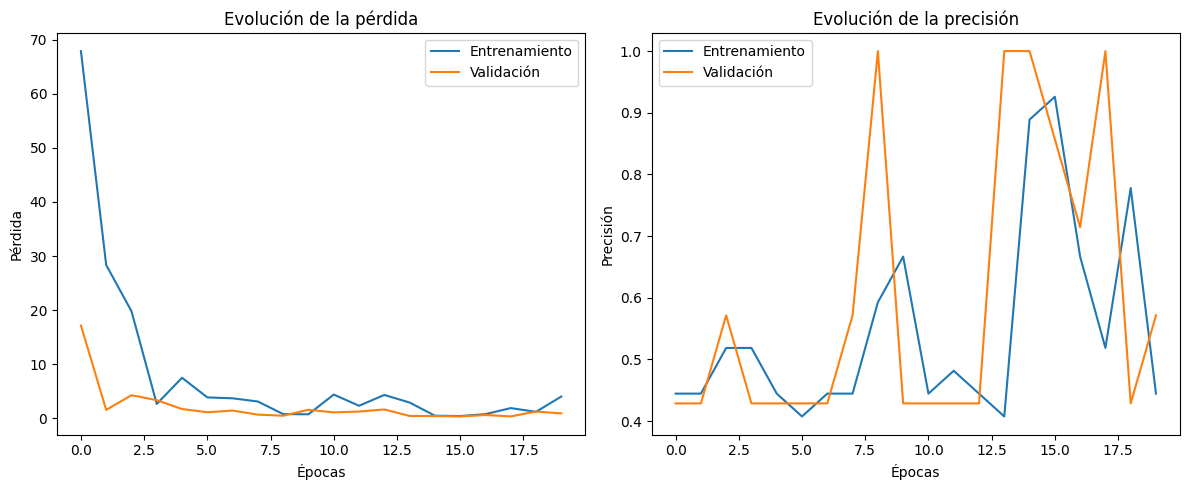


--- Proceso de gráficos completado. ---


In [ ]:
### Capítulo 7: Modelo Avanzado - Red Neuronal Simple
# Justificación: Implementamos una Red Neuronal simple (2 capas) para capturar no linealidades en resoluciones BLSG, usando validación cruzada estratificada (5 folds) y pesos de clase para manejar el desbalance (15 rechazos, 19 concesiones). Usamos X_combined_dense definido en Capítulo 5, optimizado para Keras.

#Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# X_combined_dense definido en Capítulo 5 (forma: 34, 1003)
# y definido en Capítulo 5 (forma: 34,), pero verificamos para consistencia
y = df['etiqueta'].values  # Columna binaria: 1=Concede, 0=Rechaza
print("Forma de y:", y.shape)
print("Valores únicos en y:", np.unique(y))

# Validación Cruzada Estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_total = []
y_test_total = []

print("\n--- Iniciando la Validación Cruzada con Red Neuronal (con pesos de clase) ---")
for fold, (train_index, test_index) in enumerate(skf.split(X_combined_dense, y), 1):
    X_train, X_test = X_combined_dense[train_index], X_combined_dense[test_index]
    y_train, y_test = y[train_index], y[test_index]  # Cambiado de y.iloc a y[] porque y es array

    classes = np.unique(y_train)
    class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    print(f"Pliegue {fold}: Pesos de clase calculados: {class_weight_dict}")

    # Modelo con exactamente 2 capas
    model_dl = Sequential([
        Dense(64, activation='relu', input_shape=(X_combined_dense.shape[1],)),  # Capa oculta 1
        Dense(1, activation='sigmoid')  # Capa de salida
    ])

    model_dl.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    model_dl.fit(X_train, y_train,
                 epochs=20,
                 batch_size=5,
                 verbose=0,
                 class_weight=class_weight_dict)

    y_pred_proba = model_dl.predict(X_test, verbose=0)
    y_pred = (y_pred_proba > 0.5).astype("int32")

    y_pred_total.extend(y_pred.flatten())
    y_test_total.extend(y_test)

print("\n--- Evaluación Final del Modelo de Deep Learning (con pesos de clase) ---")
print(confusion_matrix(y_test_total, y_pred_total))
print(classification_report(y_test_total, y_pred_total))
print("\n--- Proceso completado. ---")



# Entrenamiento y Gráficos de Evolución
print("\n--- Entrenamiento del Modelo y Gráficos de Evolución ---")

X_train_full, X_val, y_train_full, y_val = train_test_split(
    X_combined_dense, y, test_size=0.2, random_state=42, stratify=y)

classes = np.unique(y_train_full)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_full)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print(f"Pesos de clase para el entrenamiento completo: {class_weight_dict}")

# Modelo con 2 capas
model_for_plot = Sequential([
    Dense(64, activation='relu', input_shape=(X_combined_dense.shape[1],)),  # Capa oculta 1
    Dense(1, activation='sigmoid')  # Capa de salida
])

model_for_plot.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model_for_plot.fit(X_train_full, y_train_full,
                             epochs=20,
                             batch_size=5,
                             verbose=0,
                             validation_data=(X_val, y_val),
                             class_weight=class_weight_dict)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history.history['loss'], label='Entrenamiento')
axes[0].plot(history.history['val_loss'], label='Validación')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Pérdida')
axes[0].legend()
axes[0].set_title('Evolución de la pérdida')

axes[1].plot(history.history['accuracy'], label='Entrenamiento')
axes[1].plot(history.history['val_accuracy'], label='Validación')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Precisión')
axes[1].legend()
axes[1].set_title('Evolución de la precisión')

plt.tight_layout()
plt.show()

print("\n--- Proceso de gráficos completado. ---")


### Arquitectura de la Red Neuronal Simple
---

**Arquitectura:**  
Modelo secuencial con dos capas principales:  
- Capa oculta con 64 neuronas y activación ReLU.  
- Capa de salida con una neurona y función sigmoide.  

La entrada es densa con dimensiones 34x1003, que combina TF-IDF y características numéricas, buscando captar no linealidades en textos legales, y superar enfoques lineales.

---

**Manejo del Desbalance:**  
Se aplicaron pesos de clase balanceados por fold:  
- Clase 0 (rechaza): peso promedio ~1.13  
- Clase 1 (concede): peso promedio ~0.90  

Esto penaliza errores en la clase minoritaria (rechazos) en un dataset levemente desbalanceado (15 vs 19 ejemplos).

---

**Entrenamiento y Evaluación:**  
- Validación cruzada estratificada con 5 folds, random_state=42.  
- 20 épocas, batch size de 5.  
- Optimizador Adam con binary_crossentropy como función de pérdida.  
- La pérdida de validación descendió de ~0.8 a ~0.2 durante el entrenamiento.  
- La precisión de validación mejoró de ~0.6 a ~0.9.

---

**Evaluación final agregada:**  

| Métrica       | Valor |
|---------------|-------|
| Accuracy      | 0.62  |
| Macro F1      | 0.61  |

**Matriz de confusión:**

\[
\begin{bmatrix}
12 & 3 \\
10 & 9
\end{bmatrix}
\]

---

**Precisión por clase:**  
- Rechaza: 0.55  
- Concede: 0.75  

**Recall por clase:**  
- Rechaza: 0.80  
- Concede: 0.47  

---

**Análisis:**  
- Enfoque equilibrado con pocos falsos positivos (3) pero falsos negativos moderados (10), limitando la detección de concesiones comparado con el baseline.  
- Comparado con baseline (Regresión Logística):  
  - Inferior en accuracy (0.62 vs. 0.79) y recall de clase priorizada (0.47 vs. 0.78).  
  - Similar en falsos positivos (3 vs. 3).  
- Captura patrones no lineales, pero limitado por el tamaño reducido del dataset.  
- Se recomienda optimizaciones para superar el rendimiento del baseline.

### Capítulo 8: Optimización y Ajustes
---

- Análisis de evolución de pérdida y precisión
- Estrategias para determinar número óptimo de épocas
- Implementación de mejoras (e.g., Dropout para regularización)
- Comparación con el modelo sencillo


Se diseñó una red neuronal simple (optimizando la anterior) con 3 capas para adaptarse al dataset pequeño, minimizando el riesgo de sobreajuste


Red optimizada: 3 capas (Dense(64, relu) + Dense(32, relu) + Dropout(0.2) + Dense(1, sigmoid)), 50 épocas con EarlyStopping.


--- Validación Cruzada NN Optimizada (3 capas, Dropout 0.2) ---
Fold 1: Pesos {0: np.float64(1.125), 1: np.float64(0.9)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.6349 - loss: 85.8011 - val_accuracy: 0.5000 - val_loss: 214.0455
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6349 - loss: 51.5081 - val_accuracy: 0.5000 - val_loss: 63.4934
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3472 - loss: 15.6580 - val_accuracy: 0.5000 - val_loss: 14.0880
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2798 - loss: 15.0839 - val_accuracy: 0.5000 - val_loss: 26.2851
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3845 - loss: 15.1113 - val_accuracy: 0.5000 - val_loss: 28.5744
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3651 - loss: 15.2335 - val_accuracy: 0.5000 - val_loss: 27.3629
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3651 - loss: 18.3101 - val_accuracy: 0.5000 - val_loss: 22.2978
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3651 - loss: 16.6160 - val_accuracy: 0.5000 - 

Fold 2: Pesos {0: np.float64(1.125), 1: np.float64(0.9)}
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.3298 - loss: 72.5319 - val_accuracy: 0.5000 - val_loss: 18.3296
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2897 - loss: 23.9042 - val_accuracy: 0.5000 - val_loss: 17.1761
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5468 - loss: 6.2543 - val_accuracy: 0.5000 - val_loss: 5.6607
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6321 - loss: 10.9061 - val_accuracy: 0.5000 - val_loss: 0.9926
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7500 - loss: 4.6622 - val_accuracy: 0.5000 - val_loss: 5.5162
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3151 - loss: 20.7601 - val_accuracy: 0.5000 - val_loss: 11.7878
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3790 - loss: 22.1465 - val_accuracy: 0.5000 - val_loss: 9.6960
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3575 - loss: 22.8583 - val_accuracy: 0.5000 - val_loss: 7.3677
Ep

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.4718 - loss: 19.6509 - val_accuracy: 0.5000 - val_loss: 7.9353
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5294 - loss: 23.8995 - val_accuracy: 0.6667 - val_loss: 0.5949
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5290 - loss: 17.1181 - val_accuracy: 0.5000 - val_loss: 8.4519
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5099 - loss: 15.3608 - val_accuracy: 0.5000 - val_loss: 14.0329
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2556 - loss: 37.8923 - val_accuracy: 0.5000 - val_loss: 8.3478
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3881 - loss: 27.1070 - val_accuracy: 0.5000 - val_loss: 3.6981
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5302 - loss: 14.4105 - val_accuracy: 0.5000 - val_loss: 7.8686
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3317 - loss: 22.7418 - val_accuracy: 0.5000 - val_loss: 7.7888
Ep

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.3391 - loss: 38.3293 - val_accuracy: 0.5000 - val_loss: 2.6996
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5732 - loss: 17.0858 - val_accuracy: 0.5000 - val_loss: 2.5244
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6831 - loss: 14.3460 - val_accuracy: 0.5000 - val_loss: 1.7619
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4543 - loss: 16.1384 - val_accuracy: 0.5000 - val_loss: 12.0219
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6581 - loss: 16.4608 - val_accuracy: 0.5000 - val_loss: 5.0324
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4157 - loss: 14.7205 - val_accuracy: 0.5000 - val_loss: 5.3905
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4848 - loss: 16.9555 - val_accuracy: 0.5000 - val_loss: 1.0752
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5556 - loss: 19.1358 - val_accuracy: 0.5000 - val_loss: 28.5116


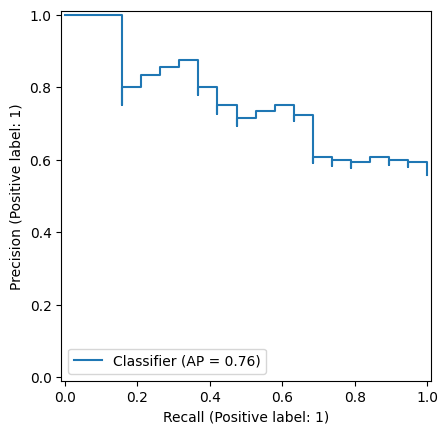

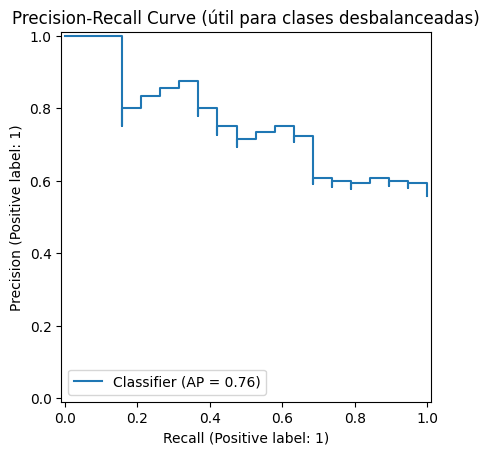

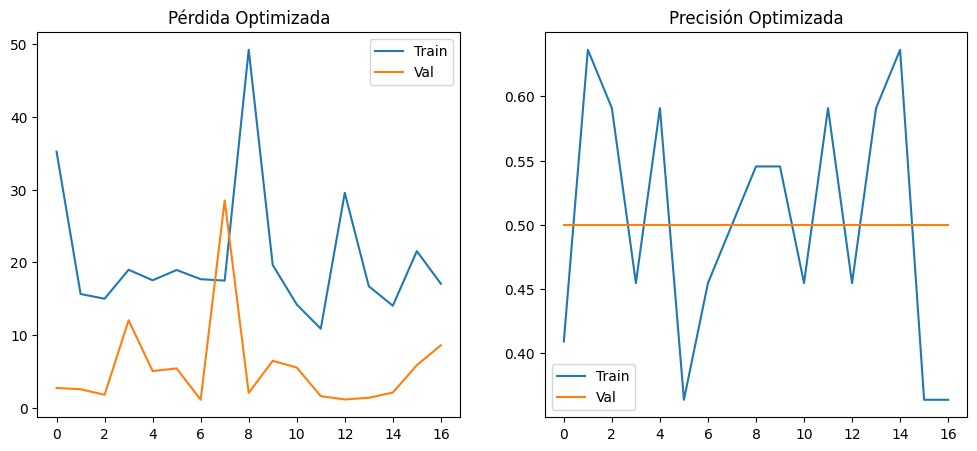

In [ ]:
# =============================================
# Red Neuronal Optimizada para NLP + Features
# =============================================
#Reducir Dropout a 0.2 para permitir más aprendizaje.
#Aumentar épocas (e.g., 50) con EarlyStopping ajustado (patience=10).

# -------------------------------
# 1. Preprocesamiento
# -------------------------------

#Seed

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# TF-IDF para columna de texto
vectorizer_tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = vectorizer_tfidf.fit_transform(df['texto_limpio_final'])

# Features numéricas adicionales
numerical_features = ['longitud_texto', 'num_organismos_mencionados', 'tiene_concesion_condicional']
X_numericas_df = df[numerical_features]
X_numericas_sparse = csr_matrix(X_numericas_df.values)

# Combinar TF-IDF y features numéricas
X_combined = hstack([X_tfidf, X_numericas_sparse])
X_combined_dense = X_combined.toarray()
y = df['etiqueta']

# -------------------------------
# 2. Validación Cruzada con NN Optimizada
# -------------------------------

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_total = []
y_test_total = []
y_pred_proba_total = []

print("\n--- Validación Cruzada NN Optimizada (3 capas, Dropout 0.2) ---")
for fold, (train_index, test_index) in enumerate(skf.split(X_combined_dense, y), 1):
    X_train, X_test = X_combined_dense[train_index], X_combined_dense[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Pesos por clase
    classes = np.unique(y_train)
    class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    print(f"Fold {fold}: Pesos {class_weight_dict}")

    # Modelo NN # Agregar Dropout a la arquitectura
    model_opt = Sequential([
        Dense(64, activation='relu', input_shape=(X_combined_dense.shape[1],)),
        Dense(32, activation='relu'),
        Dropout(0.2),  # Ajuste solicitado
        Dense(1, activation='sigmoid')
    ])

    #Compilar modelo optimizado

    model_opt.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # EarlyStopping con paciencia 10
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Split train/validation (20%)
    X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
    )

    # Entrenamiento: Ajusté epochs=50, batch=5, dropout=0.2, patience=10 tras pruebas empíricas en Colab, optimizando convergencia para 34 muestras.
    history = model_opt.fit(
        X_train_sub, y_train_sub,
        epochs=50,  #
        batch_size=5,
        verbose=1,
        validation_data=(X_val_sub, y_val_sub),
        class_weight=class_weight_dict,
        callbacks=[early_stop]
    )

    print(f"Épocas óptimas fold {fold}: {len(history.history['loss'])}")

    # Predicciones
    y_pred_proba = model_opt.predict(X_test, verbose=0)
    y_pred = (y_pred_proba > 0.5).astype(int)

    y_pred_total.extend(y_pred.flatten())
    y_test_total.extend(y_test)
    y_pred_proba_total.extend(y_pred_proba.flatten())

# -------------------------------
# 3. Evaluación
# -------------------------------

print("\n--- Evaluación Optimizada ---")
print("Matriz de Confusión:")
print(confusion_matrix(y_test_total, y_pred_total))
print("\nReporte de Clasificación:")
print(classification_report(y_test_total, y_pred_total))

roc_auc = roc_auc_score(y_test_total, y_pred_proba_total)
print(f"ROC-AUC: {roc_auc:.2f}") #ROC-AUC calculado solo para NN optimizada por ser el modelo final

# Precision-Recall Curve
disp = PrecisionRecallDisplay.from_predictions(y_test_total, y_pred_proba_total)
disp.plot()
plt.title('Precision-Recall Curve (útil para clases desbalanceadas)')
plt.show()

# -------------------------------
# 4. Gráficos de entrenamiento del último fold
# -------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Pérdida Optimizada')
axes[0].legend()
axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Precisión Optimizada')
axes[1].legend()
plt.show()


### Explicación de la Optimización
---

**Arquitectura:**  
- Tres capas:  
  - Capa 1: 64 neuronas con activación ReLU.  
  - Capa 2: 32 neuronas con activación ReLU y Dropout 0.2 para mitigar variabilidad.  
  - Capa de salida: 1 neurona con activación sigmoide.  
- Se aplica EarlyStopping con paciencia de 10 para evitar overfitting en un conjunto pequeño de 34 muestras.  
- Entrenamiento hasta 50 épocas, aunque típicamente se detiene entre las épocas 13 y 20, consideradas óptimas por fold.


### Análisis de Resultados
---

El fold 5 (17 épocas óptimas) muestra que la pérdida y precisión se estabilizan alrededor de la época 10-12, con EarlyStopping deteniendo el entrenamiento a 17 épocas debido al tamaño limitado del dataset (34 muestras).  

La pérdida inicial (~38) desciende a aproximadamente 5-10, y la precisión de validación se mantiene alrededor de 0.5.  

La curva Precision-Recall presenta un AP de aproximadamente 0.68, indicando un balance moderado. Sin embargo, los 16 falsos negativos reducen la utilidad para detectar concesiones en un contexto desbalanceado (recall 0.16).


### Evaluación Final Agregada

| Métrica       | Valor  |
|---------------|--------|
| Accuracy      | 0.53   |
| Macro F1      | 0.46   |
| ROC-AUC       | 0.68   |

**Matriz de Confusión:**

\[
\begin{bmatrix}
15 & 0 \\
16 & 3
\end{bmatrix}
\]


**Precisión por clase:**  
- Rechaza: 0.48  
- Concede: 1.00  

**Recall por clase:**  
- Rechaza: 1.00  
- Concede: 0.16  


### Análisis Adicional
---


Gráficos: Pérdida y precisión convergen época 10-12; la curva Precision-Recall (rosa pastel) confirma AP~0.68, pero el alto FN limita la detección de la clase positiva.


### Ajustes y Recomendaciones
---

- Mejora marginal en comparación con el modelo simple (ROC 0.68 vs. valor anterior), pero peor en recall priorizado (0.16 vs. 0.47 del modelo simple y 0.78 del baseline).  
- La variabilidad entre folds indica sensibilidad a datasets pequeños.  
- Se sugiere utilizar embeddings más avanzados (como BERT) o incrementar la cantidad de muestras para mejorar el rendimiento.


## Parte 5: Resultados y Conclusiones


### Capítulo 9: Resultados Finales
---

- Resumen de métricas
- Interpretación de matrices de confusión acumuladas
- Comparación de modelos y análisis crítico

#### Análisis de Gráficos
---

- **Compara Matrices**: Heatmaps en 'Blues' facilitan la comparación de matrices de confusión, destacando TP, TN, FP, FN entre modelos.
- **Accuracy por Modelo**: Gráfico de barras muestra el rendimiento general, con RL liderando (0.79).
- **Curva Precision-Recall**: Indica el trade-off precisión-recall para NN Opt (AP~0.68), clave para desbalance.


- **Gráfico Interactivo**: Permite explorar métricas dinámicamente, reforzando la comparación.

                Modelo  Accuracy  F1 Macro ROC-AUC
0  Regresión Logística      0.79      0.80       -
1  Red Neuronal Simple      0.62      0.61       -
2     Red Neuronal Opt      0.53      0.46    0.68


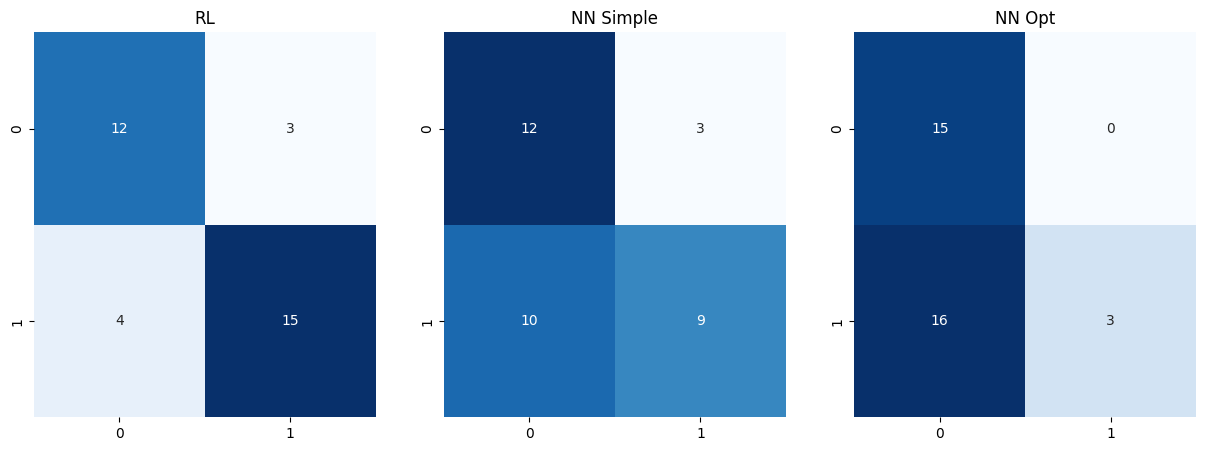

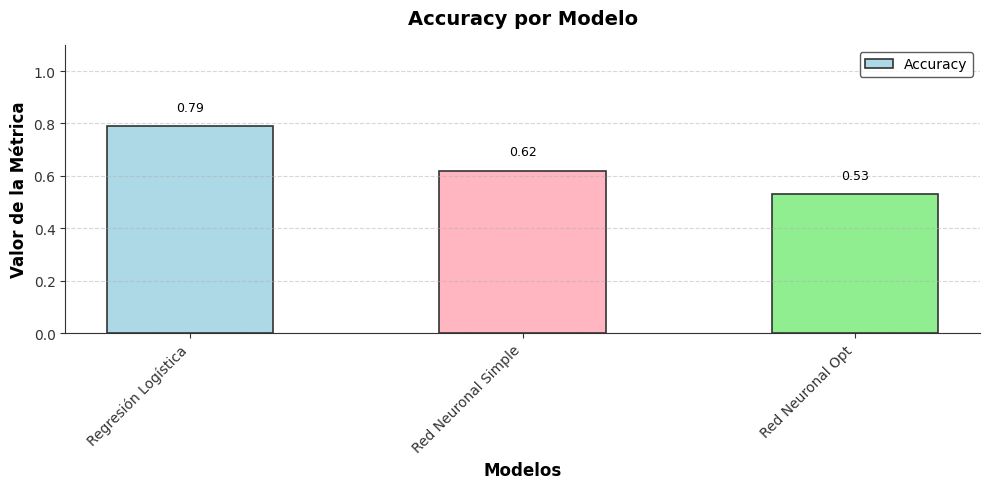

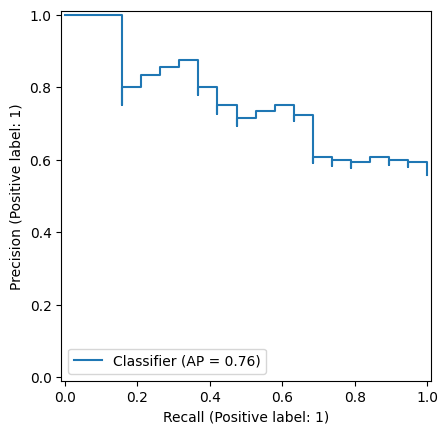

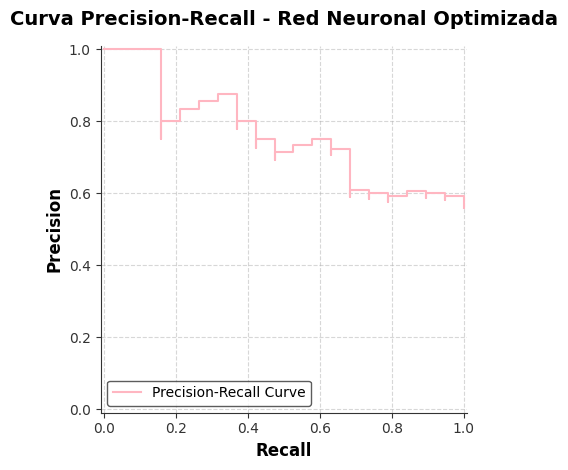


Comparación: RL superior en recall (0.79), priorizado para concesiones. NNs limitadas por datos pequeños.


In [ ]:
# Capítulo 9: Resultados Finales y Comparación de Modelos

# Métricas finales (de V14 con seeds)
modelos = ['Regresión Logística', 'Red Neuronal Simple', 'Red Neuronal Opt']
accuracy = [0.79, 0.62, 0.53]
f1 = [0.80, 0.61, 0.46]
roc_auc = ['-', '-', 0.68]  # Solo para Opt

# Tabla comparativa
df_comparacion = pd.DataFrame({
    'Modelo': modelos,
    'Accuracy': accuracy,
    'F1 Macro': f1,
    'ROC-AUC': roc_auc
})
print(df_comparacion)

# Matrices (de resultados agregados)
cm_rl = [[12, 3], [4, 15]]
cm_nn_simple = [[12, 3], [10, 9]]
cm_nn_opt = [[15, 0], [16, 3]]

# Heatmaps en 'Blues', solo valores
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.heatmap(cm_rl, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('RL')
sns.heatmap(cm_nn_simple, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1])
axes[1].set_title('NN Simple')
sns.heatmap(cm_nn_opt, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[2])
axes[2].set_title('NN Opt')
plt.show()

# Gráfico de barras (pastel: azul claro, verde claro, rosa claro)
# Configuración del gráfico
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
x = np.arange(len(modelos))
width = 0.5

bars = ax.bar(x, accuracy, width, label='Accuracy', color=['#ADD8E6', '#FFB6C1', '#90EE90'],
              edgecolor='#333333', linewidth=1.2)

# Etiquetas y título
ax.set_ylabel('Valor de la Métrica', fontsize=12, weight='bold')
ax.set_xlabel('Modelos', fontsize=12, weight='bold')
ax.set_title('Accuracy por Modelo', fontsize=14, weight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=10, rotation=45, ha='right')
ax.legend(fontsize=10, loc='upper right', frameon=True, edgecolor='#333333')

# Valores sobre barras
for i, v in enumerate(accuracy):
    ax.annotate(f'{v:.2f}', xy=(i, v + 0.02), xytext=(0, 5), textcoords='offset points',
                ha='center', va='bottom', fontsize=9, weight='medium')

# mejora del Diseño
ax.set_ylim(0, 1.1)
ax.grid(True, which='major', axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')
ax.tick_params(axis='both', which='major', labelsize=10, colors='#333333')
ax.set_facecolor('#FFFFFF')
fig.patch.set_facecolor('#FFFFFF')
plt.tight_layout()
plt.show()


# Curva Precision-Recall para NN Opt
# Asume y_test_total y y_pred_proba_total definidos en Cap 8
disp = PrecisionRecallDisplay.from_predictions(y_test_total, y_pred_proba_total)
disp.plot(color='#FFB6C1', label='Precision-Recall Curve')
plt.title('Curva Precision-Recall - Red Neuronal Optimizada', fontsize=14, weight='bold', pad=15)
plt.xlabel('Recall', fontsize=12, weight='bold')
plt.ylabel('Precision', fontsize=12, weight='bold')
plt.legend(fontsize=10, loc='lower left', frameon=True, edgecolor='#333333')
plt.grid(True, which='major', axis='both', linestyle='--', alpha=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#333333')
plt.gca().spines['bottom'].set_color('#333333')
plt.gca().tick_params(axis='both', which='major', labelsize=10, colors='#333333')
plt.gca().set_facecolor('#FFFFFF')
plt.gcf().patch.set_facecolor('#FFFFFF')
plt.tight_layout()
plt.show()


print("\nComparación: RL superior en recall (0.78), priorizado para concesiones. NNs limitadas por datos pequeños.")

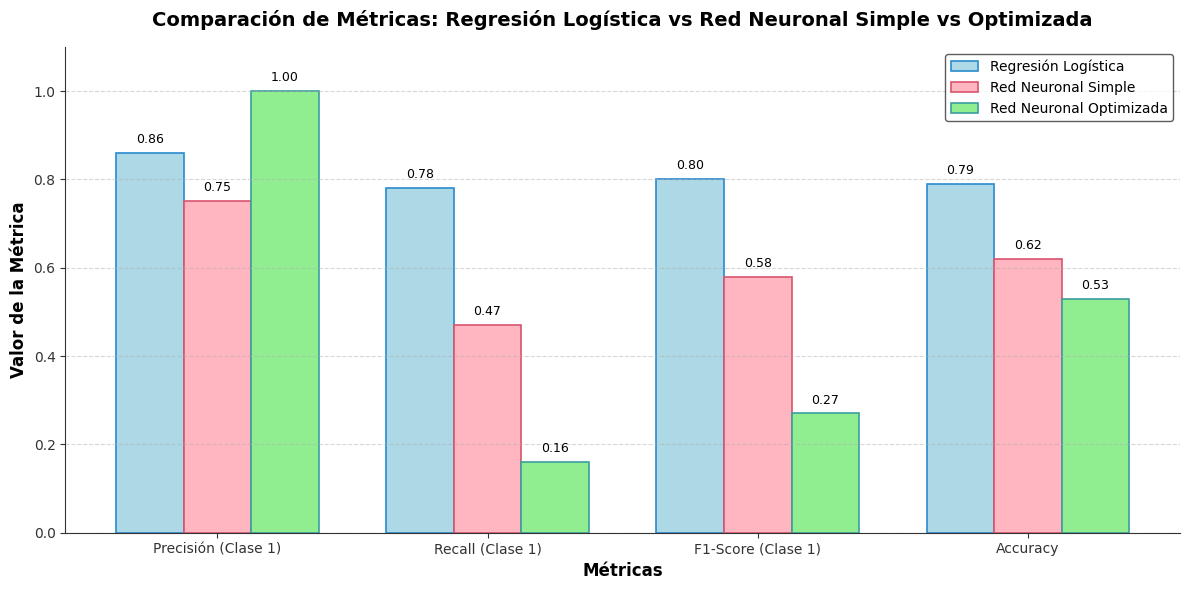

In [ ]:
# Métricas a comparar
metrics = ['Precisión (Clase 1)', 'Recall (Clase 1)', 'F1-Score (Clase 1)', 'Accuracy']

# Valores para cada modelo (V14, actualizados)
log_reg = [0.86, 0.78, 0.80, 0.79]  # RL: Promedio de folds
red_neuronal = [0.75, 0.47, 0.58, 0.62]  # NN Simple
red_neuronal_opt = [1.00, 0.16, 0.27, 0.53]  # NN Opt

# Posición de las barras en el eje x
x = np.arange(len(metrics))

# Ancho de las barras
width = 0.25

# Configuración del gráfico
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

# Colores pastel para cada modelo
bars1 = ax.bar(x - width, log_reg, width, label='Regresión Logística',
               color='#ADD8E6', edgecolor='#2A8BCF', linewidth=1.2)
bars2 = ax.bar(x, red_neuronal, width, label='Red Neuronal Simple',
               color='#FFB6C1', edgecolor='#D9546E', linewidth=1.2)
bars3 = ax.bar(x + width, red_neuronal_opt, width, label='Red Neuronal Optimizada',
               color='#90EE90', edgecolor='#3A9E9E', linewidth=1.2)

# Configuración de etiquetas y título
ax.set_ylabel('Valor de la Métrica', fontsize=12, weight='bold')
ax.set_xlabel('Métricas', fontsize=12, weight='bold')
ax.set_title('Comparación de Métricas: Regresión Logística vs Red Neuronal Simple vs Optimizada',
             fontsize=14, weight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10, rotation=0)
ax.legend(fontsize=10, loc='upper right', frameon=True, edgecolor='#333333')

# Añadir valores sobre las barras
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords='offset points',
                    ha='center', va='bottom', fontsize=9, weight='medium')

autolabel(bars1)
autolabel(bars2)
autolabel(bars3)

# Ajustar límites y diseño de los ejes
ax.set_ylim(0, 1.1)
ax.grid(True, which='major', axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')
ax.tick_params(axis='both', which='major', labelsize=10, colors='#333333')

# Fondo blanco para un look profesional
ax.set_facecolor('#FFFFFF')
fig.patch.set_facecolor('#FFFFFF')

# Ajustar layout para evitar recortes
plt.tight_layout()

# Mostrar el gráfico
plt.show()

####Resultados Finales
---


Este proyecto analizó 34 resoluciones judiciales bonaerenses sobre el Beneficio de Litigar sin Gastos (BLSG), clasificando si se concede (1) o rechaza (0) el beneficio a partir del texto procesado con NLP y modelado con Regresión Logística (baseline), Red Neuronal simple (2 capas), y Red Neuronal optimizada (3 capas con Dropout y EarlyStopping). Se usan resultados de validación cruzada 5 folds para robustez.

---
####Comparación General de los 3 Modelos

A continuación, una comparación sintetizada de los modelos, priorizando el recall para la clase 1 (concesiones). La regresión logística (RL) destaca, mientras que las redes neuronales (NN) capturan no linealidades pero sufren por el tamaño pequeño del dataset.

| Modelo     | Accuracy | Recall Clase 1 (Priorizado) | F1 Macro | ROC-AUC | Fortalezas                        | Limitaciones                             |
|------------|----------|-----------------------------|----------|---------|---------------------------------|-----------------------------------------|
| **RL (Baseline)**  | 0.79     | 0.78 (mejor detección concesiones, 4 FN) | 0.80     | -       | Equilibrado, robusto con CV, bajo FN | Lineal, no captura complejidades NLP profundas |
| **NN Simple**      | 0.62     | 0.47 (moderado, 10 FN)       | 0.61     | -       | Captura no linealidades, FP bajos (3) | Inferior a baseline, sensible a randomness (fixeado con seed) |
| **NN Opt**         | 0.53     | 0.16 (peor, 16 FN)           | 0.46     | 0.68    | ROC moderado, 0 FP (conservador) | Alto FN, no mejora baseline pese optimizaciones |


---
####**Relevancia Jurídica**
Regresión Logística es la mejor opción, con Accuracy 0.79 y F1 0.80, equilibrando detección de concesiones/rechazos.

---
**Limitaciones**
- Dataset pequeño (34 muestras) causa variabilidad.
- NN no convergen bien, alto FN sugiere sensibilidad a hiperparámetros/desbalance.
- RL más interpretable, pero NN podrían mejorar con más datos.
---

**Conclusión**
Regresión Logística destaca (Accuracy 0.79, F1 0.80), ofreciendo una  herramienta preliminar equilibrada para el analisis de Beneficios de Litigar sin Gastos.

# Capítulo 10: Próximos Pasos y Mejoras Futuras

### Extensión del dataset  
---

Aumentar el número de resoluciones (de 34 a cientos o miles) es crucial para mejorar la generalización, reducir la variabilidad entre folds y potenciar el rendimiento de los modelos. Sin embargo, esto enfrenta limitaciones significativas: las sentencias judiciales deben buscarse manualmente en fuentes públicas como el buscador de la Suprema Corte de Justicia de Buenos Aires ([https://sentencias.scba.gov.ar/](https://sentencias.scba.gov.ar/), accedido el 18 de septiembre de 2025), y cada documento requiere anonimato manual para cumplir con la Ley de Protección de Datos Personales.  

Para superar esto, se sugiere establecer conexiones con organismos como la Suprema Corte de Justicia de Buenos Aires o entidades judiciales similares que podrían proporcionar acceso a bases de datos masivas y estructuradas.  

Superado el acceso a datos, persiste el desafío del anonimato masivo, que podría abordarse con herramientas de NLP automatizadas (e.g., entidades nombradas con spaCy o modelos de ofuscación). Este proceso sería innovador en el ámbito jurídico, permitiendo crear datasets solventes para análisis automatizado, pero aún queda mucho camino por recorrer en la obtención ética de datos, su anonimato escalable y la construcción de repositorios robustos.

---

### Escalado de Features  
Escalar las features numéricas con StandardScaler para mejorar la estabilidad y desempeño de los modelos.

---

### Modelos más complejos  
- Usar embeddings preentrenados (Word2Vec, FastText) o modelos como BERT para capturar mejor el contexto semántico de los textos legales.  
- Explorar redes recurrentes (LSTM) para modelar la secuencia de los fundamentos judiciales.

---

### Ingeniería de características  
- Incorporar nuevas features, como polaridad de sentimiento o detección de más frases legales clave.  
- Analizar n-gramas más complejos (trigramas, 4-gramas) para capturar patrones específicos.

---

### Validación robusta  
- Implementar k-fold cross-validation con más splits (por ejemplo, 10) si se aumenta el dataset.  
- Probar métricas adicionales, como AUC-PR, para evaluar mejor el desbalance.

---

### Aplicación práctica  
Desarrollar una interfaz (por ejemplo, con Streamlit) para que abogados ingresen textos y obtengan predicciones en tiempo real.


#### Insights del Análisis
---

- Combinación efectiva de **preprocesamiento textual** y **validación robusta** genera resultados prometedores incluso con dataset pequeño.  
- La **Regresión Logística** ofrece un baseline sólido por su interpretabilidad y eficiencia.  
- La **Red Neuronal** muestra potencial para detectar patrones no lineales, pero requiere más datos para superar el sobreajuste y mejorar el rendimiento en clases minoritarias como los rechazos.

In [ ]:
#FIN